In [ ]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [ ]:
start=time.perf_counter()

In [ ]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 30 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 26.48 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149373 entries, 0 to 149372
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 491.2+ MB
None


In [ ]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [ ]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40982

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35532    86.70            5450
                        recoveries_elo_p90sq_3      35532    86.70            5450
                               tackles_p90sq_3      35532    86.70            5450
                           tackles_elo_p90sq_3      35532    86.70            5450
                                   cbi_p90sq_3      35532    86.70            5450
                               cbi_elo_p90sq_3      35532    86.70            5450
                        defensive_cont_p90sq_3      35532    86.70            5450
                    defensive_cont_elo_p90sq_3      35532    86.70            5450
                               tackles_p90sq_5      35484    86.58            5498
                           tackles_elo_p90sq_5      35484    86

In [ ]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132383,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132385,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132387,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132389,Bukayo Saka,24.0,0.0,Leeds,0.356240
132391,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132353,Bukayo Saka,26.0,1.0,Brentford,0.356240
132371,Bukayo Saka,27.0,5.0,Spurs,0.353169
132393,Bukayo Saka,28.0,2.0,Chelsea,0.353025
132394,Bukayo Saka,29.0,9.0,Brighton,0.350034
132395,Bukayo Saka,30.0,3.0,Everton,0.347214


In [ ]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [ ]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [ ]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [ ]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [ ]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2541/7599

Training Set Performance:
R² Score: 0.8391
RMSE: 13.1722
MAE: 10.8874

Test Set Performance:
R² Score: 0.3180
RMSE: 26.9922
MAE: 21.6464

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.257508
    opp_team_elo_p90sq_3    0.057187
           minutes_elo_3    0.038147
    opp_team_elo_p90sq_5    0.023715
       team_elo_p90sq_at    0.013833
       team_elo_p90sq_10    0.013616
   opp_team_elo_p90sq_at    0.012772
        team_elo_p90sq_3    0.012729
        team_elo_p90sq_5    0.012176
          opp_team_elo_5    0.009150
            bps_p90sq_at    0.008857
            opp_team_elo    0.008575
   opp_team_elo_p90sq_10    0.008387
                team_elo    0.007727
                elo_diff    0.007060
          opp_team_elo_3    0.006773
opp_team_elo_elo_p90sq_3    0.006752
         opp_team_elo_10    0.006457
   clean_sheets_p90sq_at    0.006422
 goals_conceded_p90sq_at    0.006298


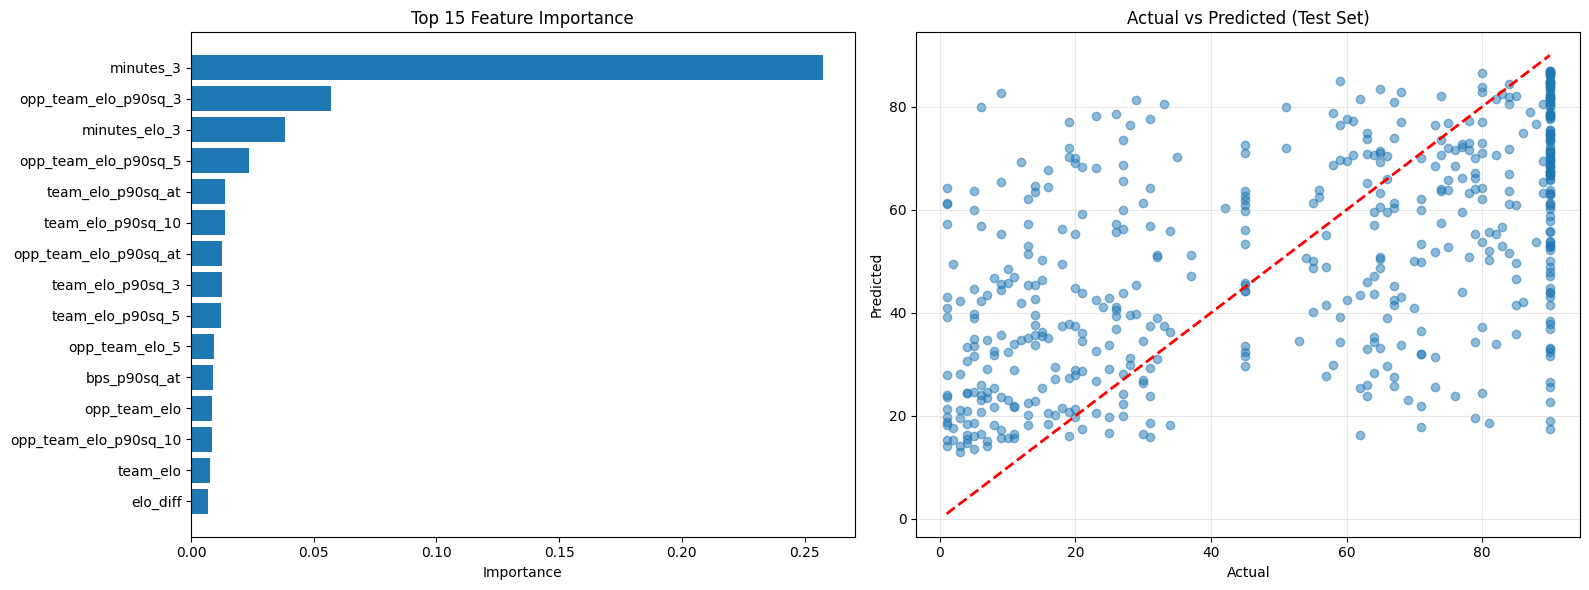

Cleaned df size: 8804/28366

Training Set Performance:
R² Score: 0.6561
RMSE: 18.8157
MAE: 15.4438

Test Set Performance:
R² Score: 0.3153
RMSE: 26.5430
MAE: 21.5709

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.373408
  opp_team_elo_p90sq_10    0.026009
   opp_team_elo_p90sq_3    0.024379
          minutes_elo_3    0.019727
   opp_team_elo_p90sq_5    0.014218
             minutes_10    0.011957
                 bps_10    0.010006
        xg_over_g_ratio    0.009065
             bps_elo_10    0.008131
      minutes_elo_p90_5    0.007508
           opp_team_elo    0.007321
         minutes_elo_10    0.007317
                  bps_3    0.007083
       team_elo_p90sq_5    0.006837
  opp_team_elo_p90sq_at    0.006625
goals_conceded_p90sq_at    0.006276
      team_elo_p90sq_10    0.006197
         opp_team_elo_5    0.005943
  clean_sheets_p90sq_at    0.005902
         opp_team_elo_3    0.005890


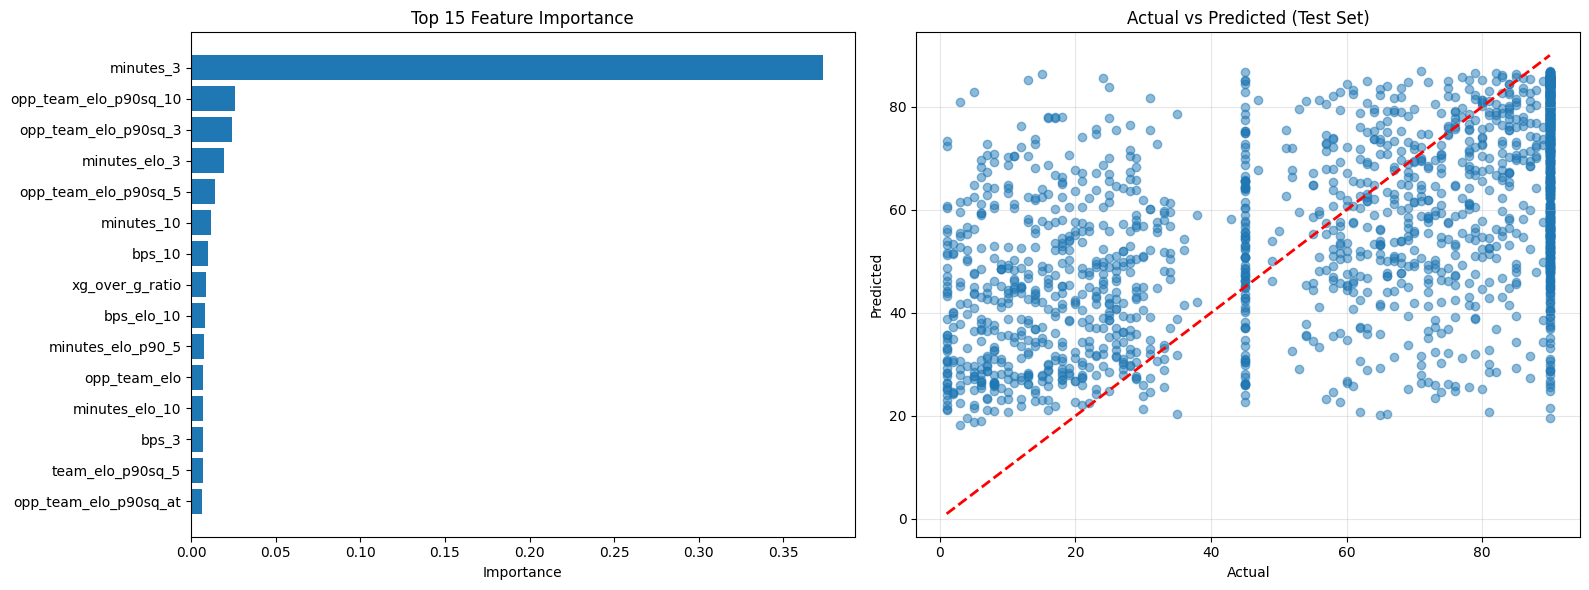

Cleaned df size: 5422/20446

Training Set Performance:
R² Score: 0.6747
RMSE: 16.8489
MAE: 12.6349

Test Set Performance:
R² Score: 0.2140
RMSE: 25.3498
MAE: 18.8283

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.130842
        team_elo_p90sq_3    0.066348
    opp_team_elo_p90sq_3    0.051103
   opp_team_elo_p90sq_10    0.014843
       xassists_p90sq_at    0.012794
       team_elo_p90sq_10    0.012779
         xg_over_g_ratio    0.012342
           minutes_elo_3    0.010781
              minutes_10    0.010595
            bps_p90sq_at    0.010303
          opp_team_elo_3    0.010277
         opp_team_elo_10    0.009740
            opp_team_elo    0.009732
                elo_diff    0.008739
 goals_conceded_p90sq_at    0.008494
       team_elo_p90sq_at    0.008311
xgoals_conceded_p90sq_at    0.008294
    opp_team_elo_p90sq_5    0.007841
          opp_team_elo_5    0.007808
   goals_scored_p90sq_at    0.007783


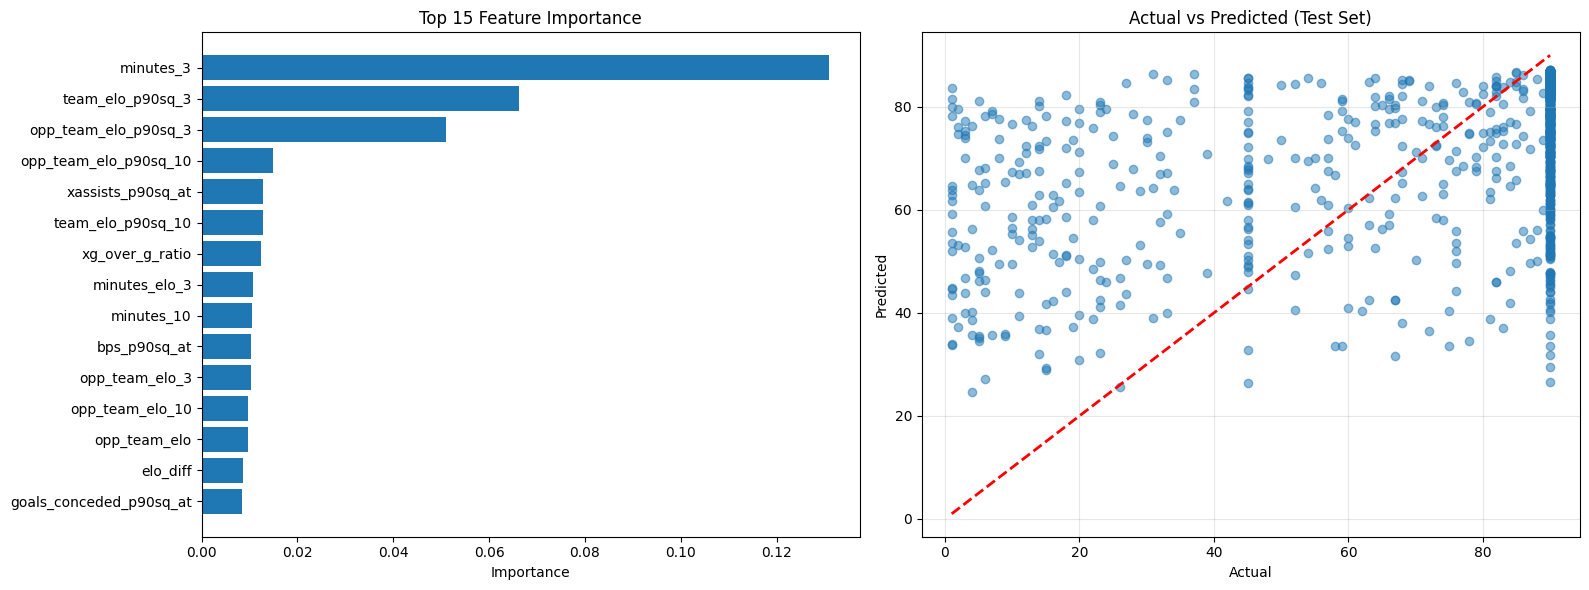

Cleaned df size: 3951/4218

Training Set Performance:
R² Score: 0.7196
RMSE: 2.7673
MAE: 0.5838

Test Set Performance:
R² Score: -0.0702
RMSE: 4.7377
MAE: 1.0564

Top 20 Feature Importances:
                 feature  importance
   opp_team_elo_p90sq_at    0.056477
            opp_team_elo    0.039424
            bps_p90sq_at    0.036582
             bps_p90sq_3    0.027421
       saves_elo_p90sq_3    0.022971
                  bps_10    0.020983
          opp_team_elo_5    0.020374
             bps_p90sq_5    0.017976
               bps_p90_3    0.016255
   total_points_p90sq_at    0.015427
          saves_p90sq_10    0.015109
          team_elo_elo_3    0.014948
       team_elo_p90sq_at    0.014698
   total_points_p90sq_10    0.013975
       saves_elo_p90sq_5    0.013926
         opp_team_elo_10    0.013793
goals_conceded_elo_p90_3    0.012701
           minutes_elo_3    0.012605
   opp_team_elo_p90sq_10    0.012310
    opp_team_elo_p90sq_5    0.012263


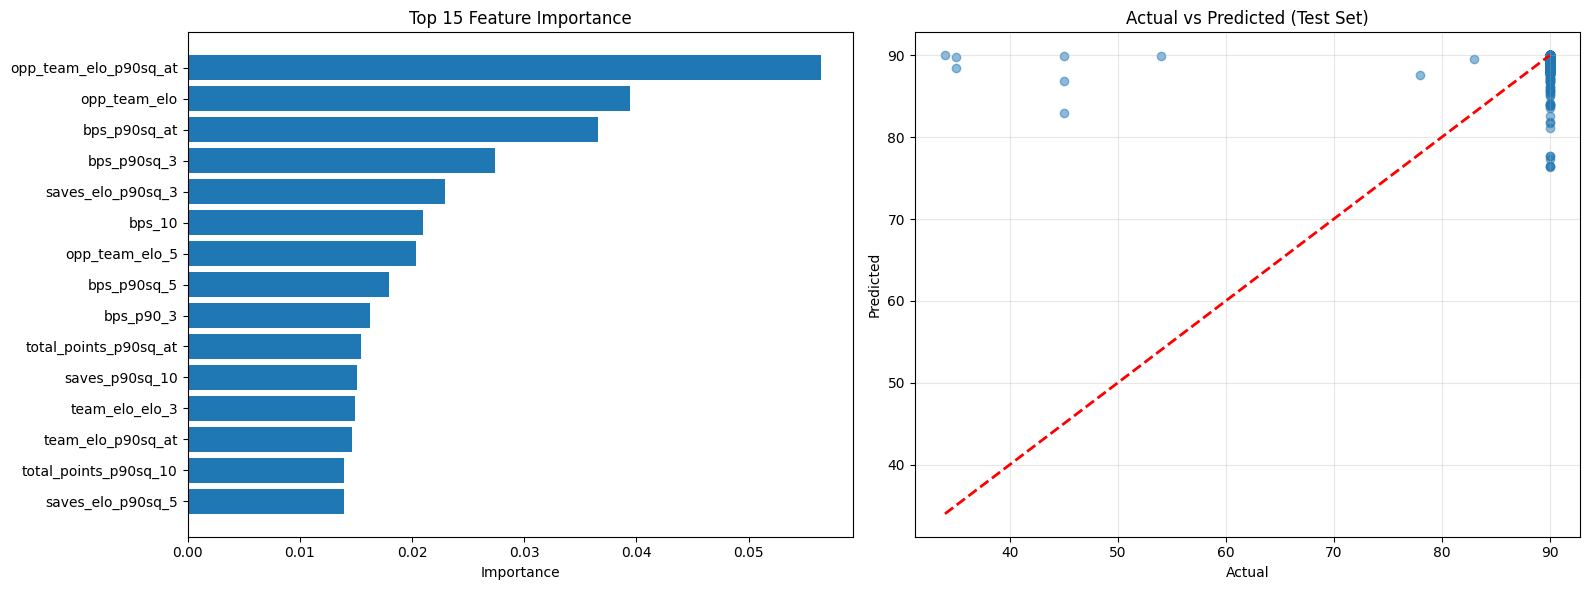

In [ ]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2649/4362

Training Set Performance:
R² Score: 0.6063
RMSE: 0.2470
MAE: 0.1987

Test Set Performance:
R² Score: -0.0213
RMSE: 0.3713
MAE: 0.2911

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.038965
  goals_scored_p90sq_at    0.033947
         opp_team_elo_5    0.020654
               team_elo    0.019917
        xg_over_g_ratio    0.019419
         bonus_p90sq_at    0.019268
         opp_team_elo_3    0.015825
           opp_team_elo    0.015470
       team_elo_p90sq_5    0.014531
        opp_team_elo_10    0.013923
             team_elo_5    0.012176
   opp_team_elo_p90sq_3    0.011976
          minutes_elo_3    0.011567
   opp_team_elo_p90sq_5    0.011492
  opp_team_elo_p90sq_10    0.011446
           bps_p90sq_at    0.011000
goals_conceded_p90sq_at    0.010969
      team_elo_p90sq_at    0.010080
       team_elo_p90sq_3    0.009894
  total_points_p90sq_10    0.009863


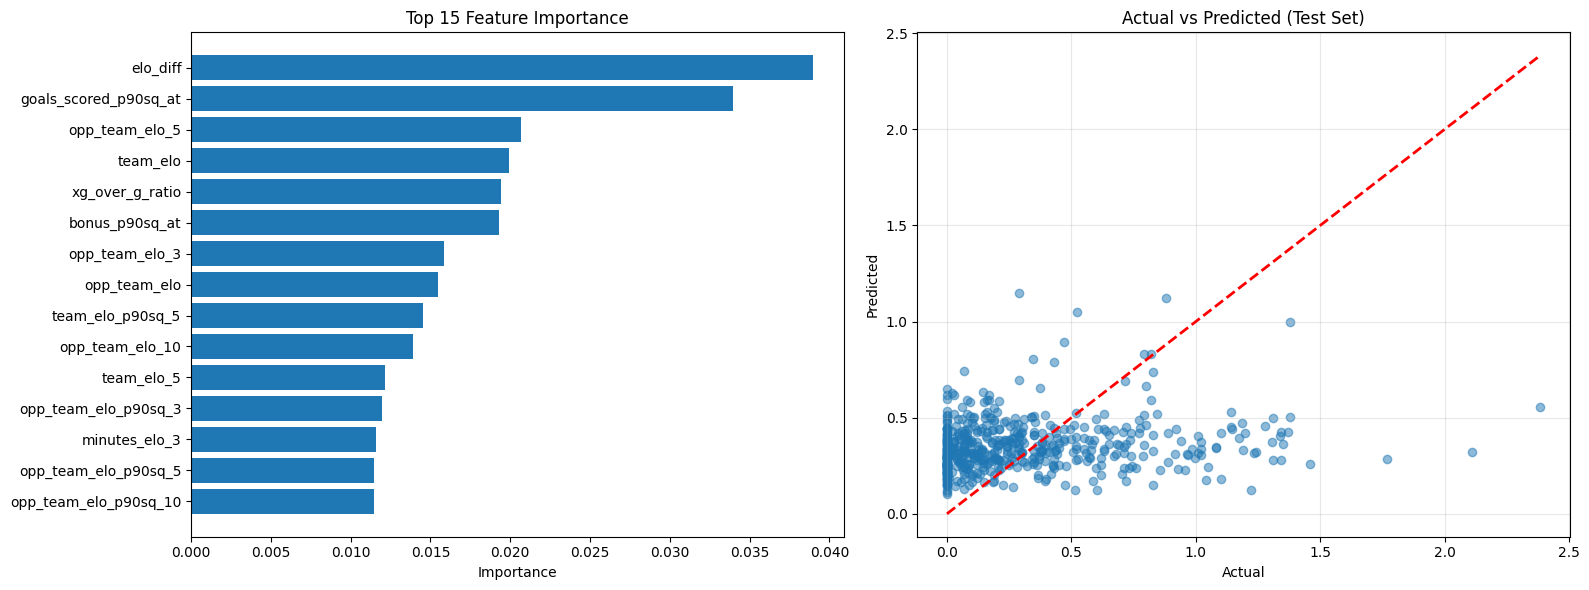

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 12220/18642

Training Set Performance:
R² Score: 0.3900
RMSE: 0.1712
MAE: 0.1159

Test Set Performance:
R² Score: 0.0772
RMSE: 0.2224
MAE: 0.1417

Top 20 Feature Importances:
              feature  importance
goals_scored_p90sq_at    0.156791
         opp_team_elo    0.034307
             elo_diff    0.020500
clean_sheets_p90sq_at    0.017412
      opp_team_elo_10    0.015123
         bps_p90sq_at    0.014818
  goals_scored_elo_10    0.014486
         bps_p90sq_10    0.014039
       bonus_p90sq_at    0.014029
       opp_team_elo_3    0.013791
  total_points_elo_10    0.013168
       opp_team_elo_5    0.012297
           bps_elo_10    0.012178
    team_elo_p90sq_at    0.011330
total_points_p90sq_at    0.011247
               bps_10    0.009615
goals_conceded_elo_10    0.009522
            bps_elo_5    0.009475
 goals_conceded_elo_3    0.009419
          bps_p90sq_3    0.009078


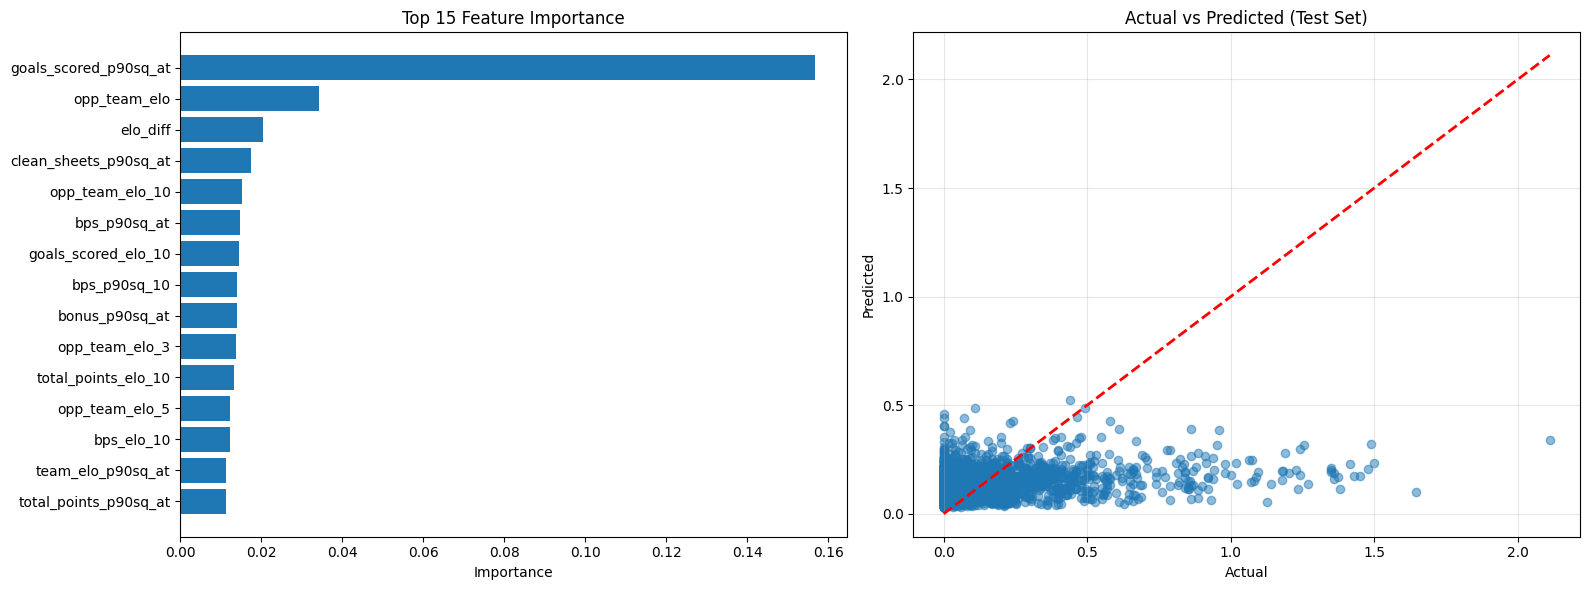

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10473/16681

Training Set Performance:
R² Score: 0.2677
RMSE: 0.0923
MAE: 0.0556

Test Set Performance:
R² Score: 0.0014
RMSE: 0.1006
MAE: 0.0595

Top 20 Feature Importances:
                    feature  importance
               opp_team_elo    0.030380
      goals_scored_p90sq_at    0.025747
                   elo_diff    0.024218
goals_conceded_elo_p90sq_10    0.018208
        goals_scored_elo_10    0.017559
      total_points_p90sq_at    0.017091
             opp_team_elo_5    0.016197
         total_points_elo_5    0.015908
      goals_conceded_elo_10    0.015853
             opp_team_elo_3    0.015738
               bps_p90sq_at    0.014586
      opp_team_elo_p90sq_10    0.014346
  goals_conceded_elo_p90_10    0.012334
    goals_conceded_p90sq_at    0.011440
            opp_team_elo_10    0.011325
              minutes_elo_5    0.011280
              minutes_elo_3    0.011258
      opp_team_elo_p90sq_at    0.010611
  

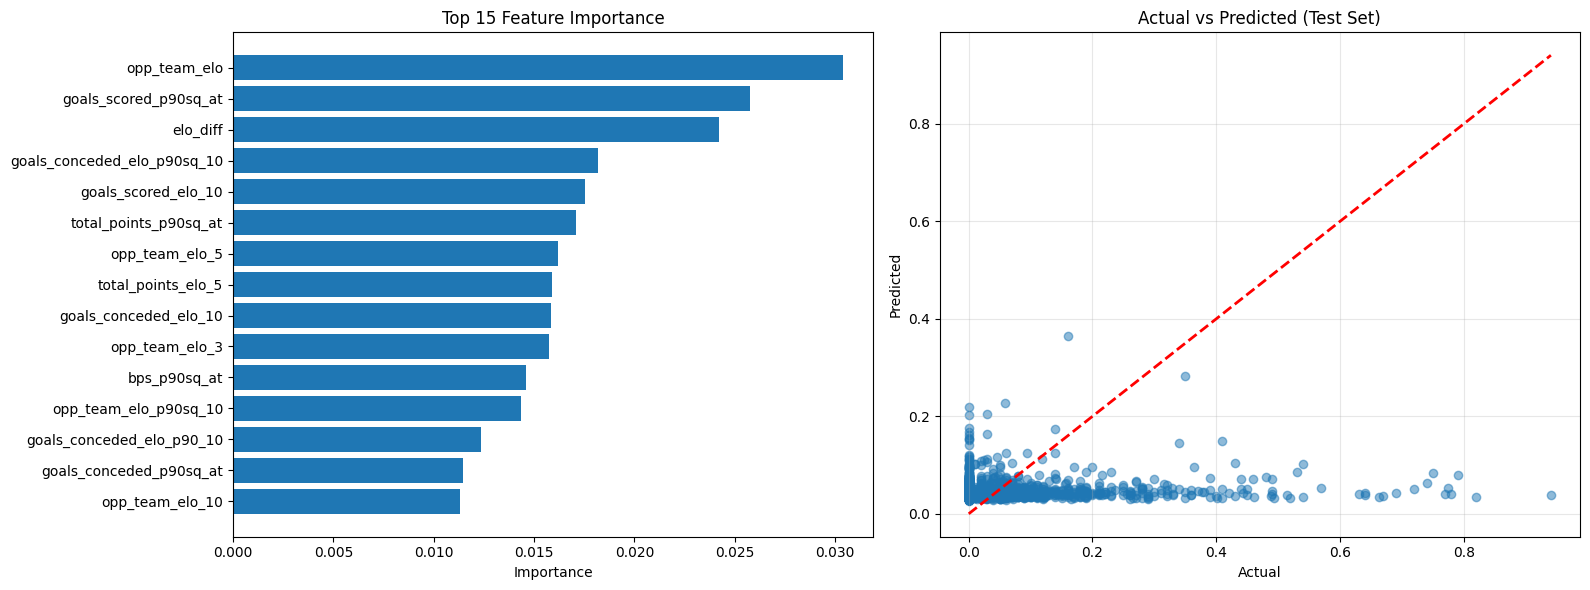

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2844/4647

Training Set Performance:
R² Score: 0.5554
RMSE: 0.0817
MAE: 0.0552

Test Set Performance:
R² Score: -0.0354
RMSE: 0.1129
MAE: 0.0711

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.040422
          opp_team_elo_3    0.028243
                elo_diff    0.026959
       minutes_elo_p90_5    0.023303
              bps_elo_10    0.018548
       minutes_elo_p90_3    0.017860
      minutes_elo_p90_10    0.016822
total_points_elo_p90sq_3    0.016820
         xg_over_g_ratio    0.015318
       team_elo_p90sq_at    0.015071
   goals_scored_p90sq_at    0.014230
            bonus_elo_10    0.013593
   total_points_p90sq_at    0.013426
               bps_p90_5    0.013299
           bps_elo_p90_3    0.012841
    total_points_p90sq_3    0.012614
    goals_conceded_elo_3    0.012495
   total_points_p90sq_10    0.012086
     total_points_elo_10    0.011946
   opp_team_elo_p90sq

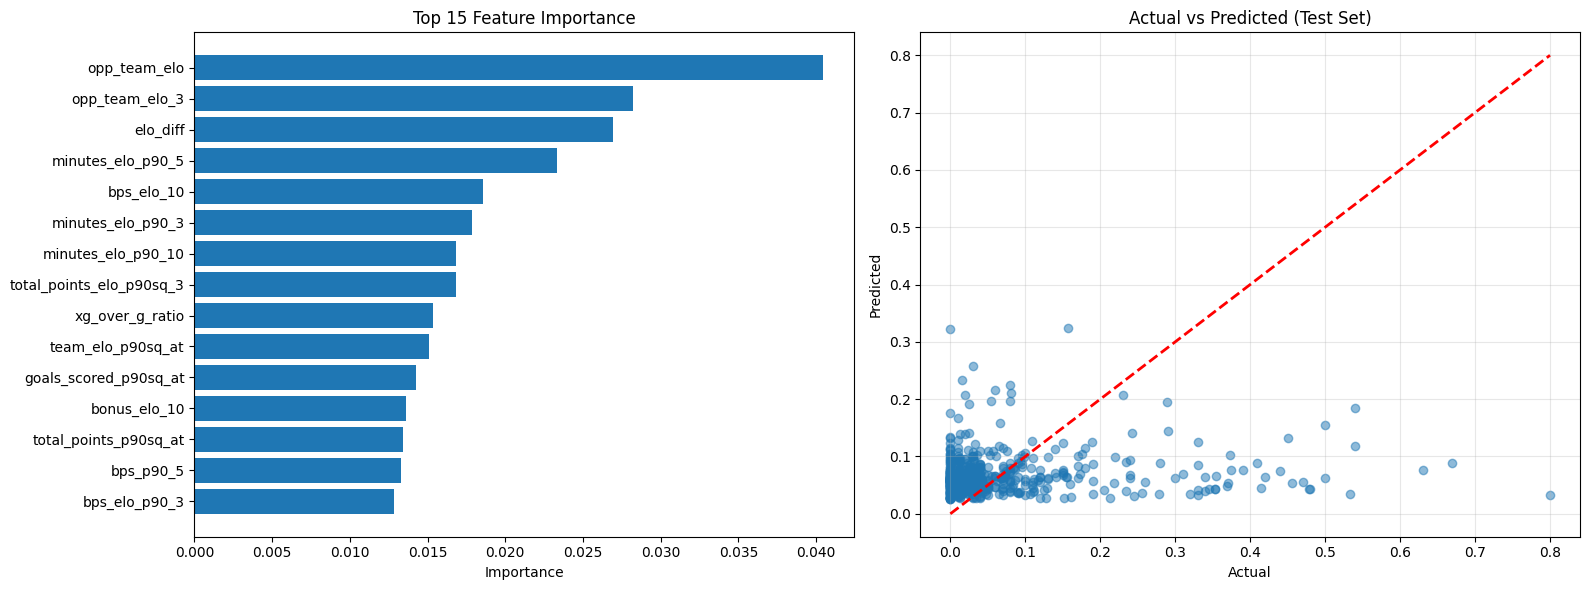

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12653/19279

Training Set Performance:
R² Score: 0.4099
RMSE: 0.1260
MAE: 0.0897

Test Set Performance:
R² Score: 0.0689
RMSE: 0.1523
MAE: 0.1048

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.101795
         bonus_p90sq_at    0.083666
    total_points_elo_10    0.023036
           opp_team_elo    0.022287
  goals_scored_p90sq_at    0.016356
           bps_p90sq_at    0.015727
         opp_team_elo_5    0.013896
  clean_sheets_p90sq_at    0.013540
             bps_elo_10    0.013205
         opp_team_elo_3    0.013089
        opp_team_elo_10    0.012694
  total_points_p90sq_at    0.011306
goals_conceded_p90sq_at    0.009996
      team_elo_p90sq_at    0.009782
                 bps_10    0.009711
           bps_p90sq_10    0.009698
    total_points_p90_10    0.009226
                  bps_3    0.008844
  opp_team_elo_p90sq_at    0.008759
             bps_p90_10    0.008688


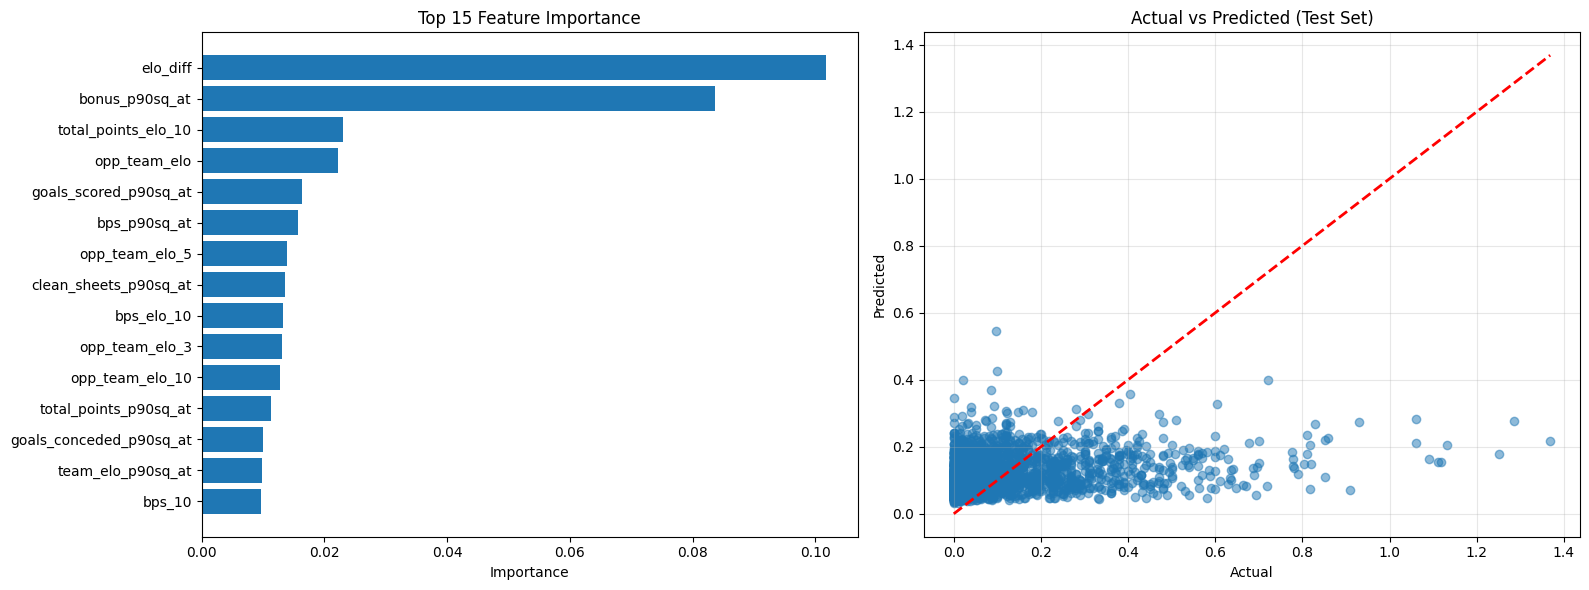

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10672/17005

Training Set Performance:
R² Score: 0.3930
RMSE: 0.0816
MAE: 0.0504

Test Set Performance:
R² Score: 0.0583
RMSE: 0.1001
MAE: 0.0583

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.096051
               elo_diff    0.044236
           opp_team_elo    0.028060
goals_conceded_p90sq_at    0.020246
                  bps_3    0.019614
  clean_sheets_p90sq_at    0.018461
               team_elo    0.017906
          bps_elo_p90_5    0.016856
  goals_scored_p90sq_at    0.016652
        opp_team_elo_10    0.015590
         opp_team_elo_3    0.015395
            bps_p90sq_5    0.014880
  opp_team_elo_p90sq_at    0.013906
              bps_p90_5    0.012503
     total_points_p90_5    0.012481
         minutes_elo_10    0.012083
    total_points_p90_10    0.011638
      team_elo_p90sq_at    0.011627
   goals_conceded_elo_3    0.010994
                 bps_10    0.010894


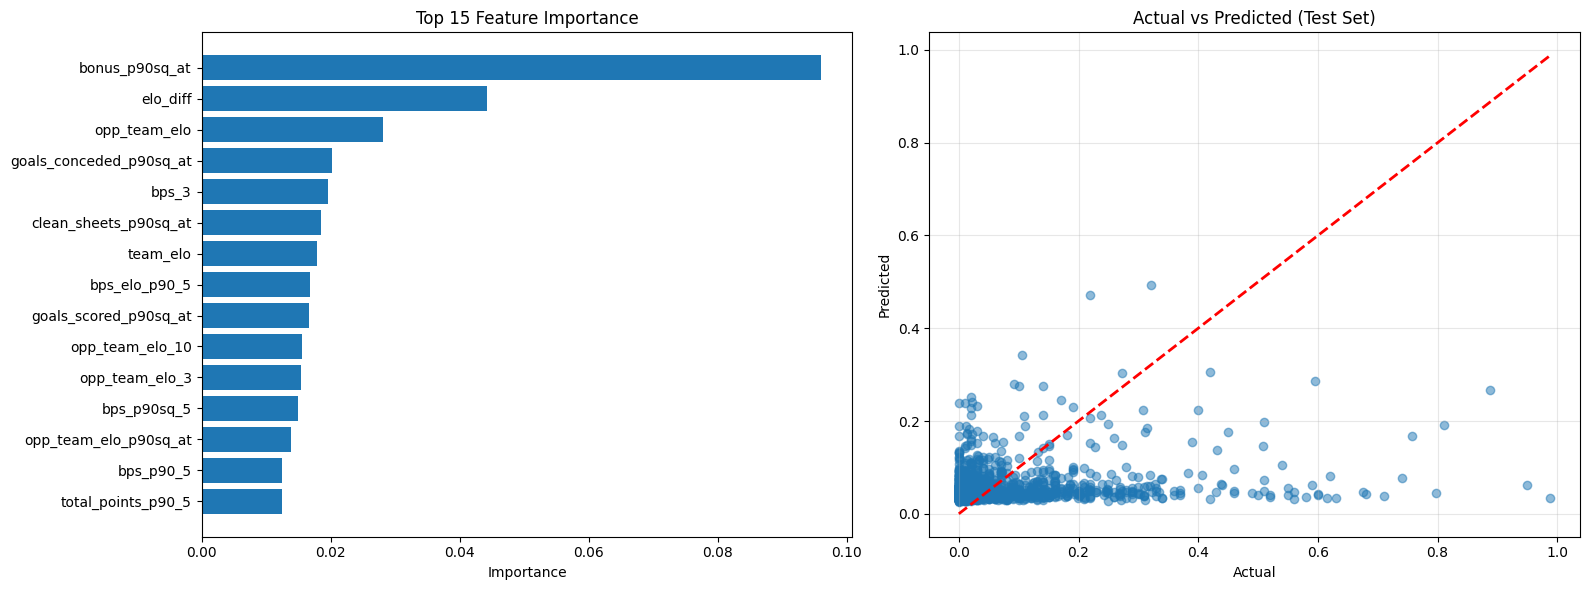

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2844/4647

Training Set Performance:
R² Score: 0.6582
RMSE: 0.5376
MAE: 0.4333

Test Set Performance:
R² Score: 0.1421
RMSE: 0.8801
MAE: 0.6791

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.152138
               opp_team_elo    0.050216
            xg_over_g_ratio    0.040344
      clean_sheets_p90sq_at    0.021762
    goals_conceded_p90sq_at    0.017046
            opp_team_elo_10    0.016760
             opp_team_elo_5    0.016258
         minutes_elo_p90_10    0.011473
        minutes_elo_p90sq_3    0.011321
    goals_conceded_p90sq_10    0.010680
             opp_team_elo_3    0.010496
             bonus_p90sq_at    0.010224
             team_elo_elo_5    0.009182
             minutes_elo_10    0.008946
       opp_team_elo_p90sq_3    0.008857
          team_elo_p90sq_at    0.008644
      goals_scored_p90sq_at    0.008401
               bps_p90sq_at    0.0

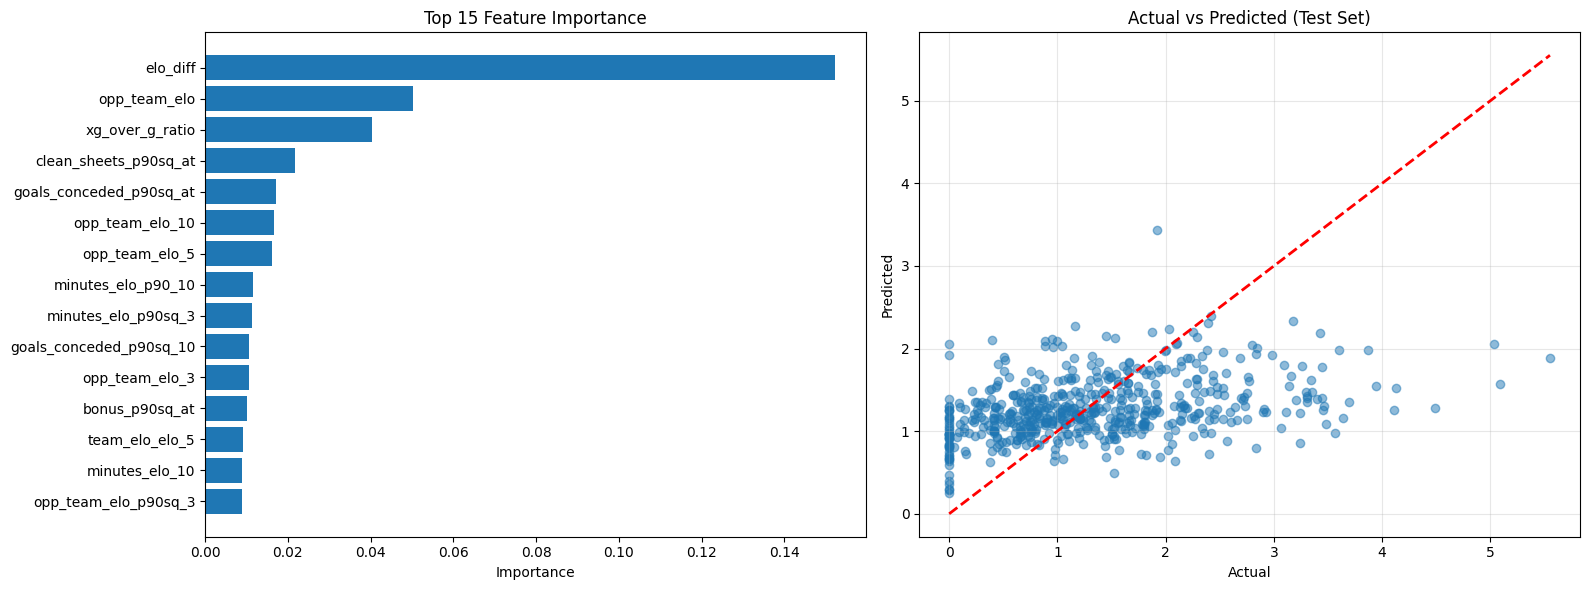

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12653/19279

Training Set Performance:
R² Score: 0.5324
RMSE: 0.6369
MAE: 0.5041

Test Set Performance:
R² Score: 0.3152
RMSE: 0.7732
MAE: 0.6067

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.260477
         opp_team_elo    0.067308
      opp_team_elo_10    0.036645
       opp_team_elo_5    0.035225
             team_elo    0.029819
       opp_team_elo_3    0.024199
          team_elo_10    0.022259
           team_elo_5    0.019829
           team_elo_3    0.019334
       team_elo_elo_3    0.018663
   opp_team_elo_elo_3    0.017861
   opp_team_elo_elo_5    0.017059
       team_elo_elo_5    0.016066
    minutes_elo_p90_3    0.015731
  minutes_elo_p90sq_3    0.015112
  opp_team_elo_elo_10    0.011409
      team_elo_elo_10    0.010956
clean_sheets_p90sq_at    0.009597
 minutes_elo_p90sq_10    0.009481
  minutes_elo_p90sq_5    0.008548


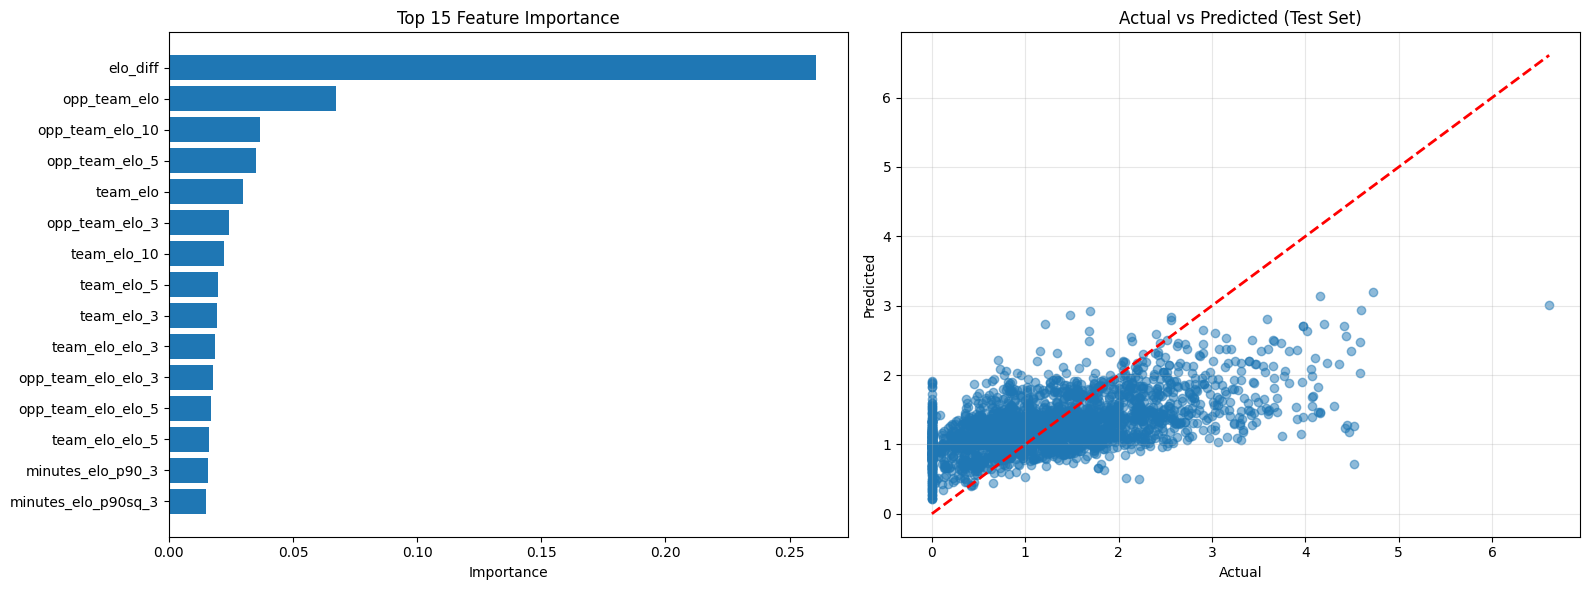

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10672/17005

Training Set Performance:
R² Score: 0.5625
RMSE: 0.6171
MAE: 0.4896

Test Set Performance:
R² Score: 0.3157
RMSE: 0.7653
MAE: 0.5999

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.205641
           opp_team_elo    0.088334
        opp_team_elo_10    0.037064
         opp_team_elo_5    0.033502
    opp_team_elo_elo_10    0.026005
         opp_team_elo_3    0.021711
               team_elo    0.018893
            team_elo_10    0.018720
  clean_sheets_p90sq_at    0.018645
             team_elo_5    0.017239
         team_elo_elo_3    0.016740
goals_conceded_p90sq_at    0.016153
     opp_team_elo_elo_5    0.015542
     opp_team_elo_elo_3    0.015519
         team_elo_elo_5    0.014696
             team_elo_3    0.013283
        team_elo_elo_10    0.011841
    minutes_elo_p90sq_3    0.011624
      minutes_elo_p90_3    0.010485
goals_conceded_p90sq_10    0.009

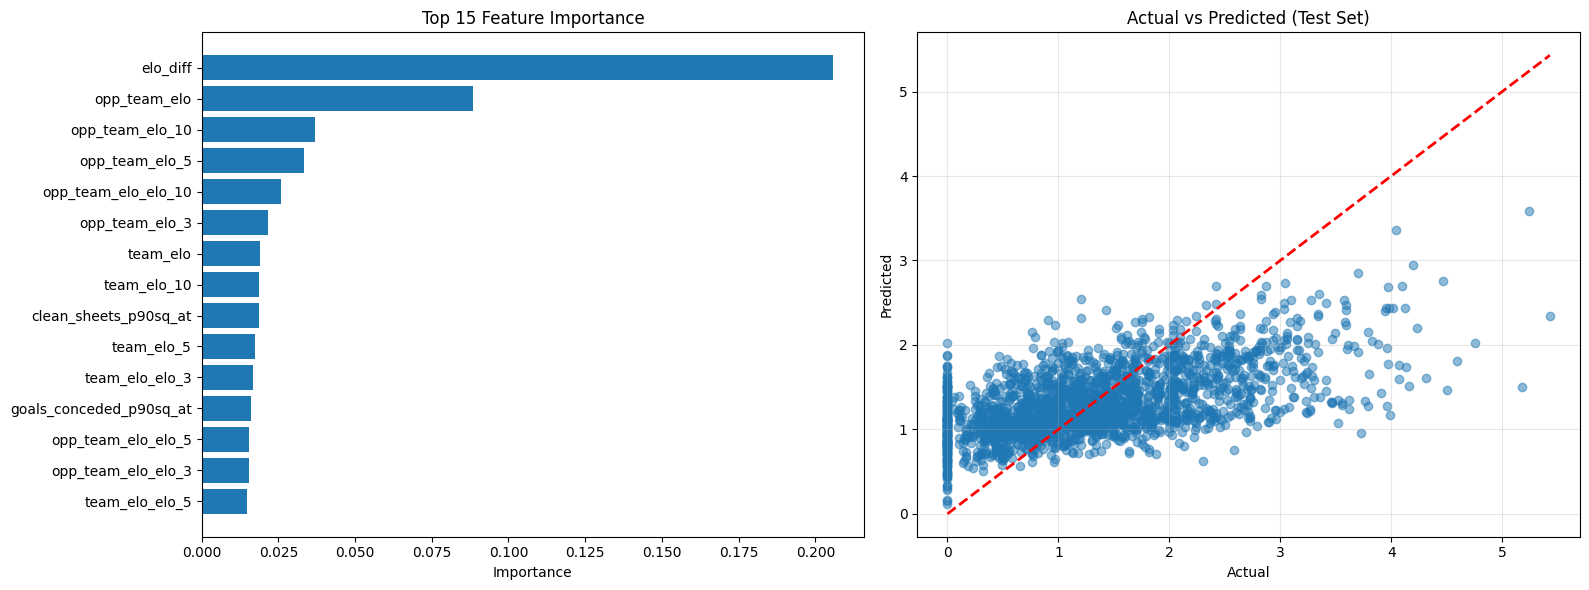

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2616/4156

Training Set Performance:
R² Score: 0.6972
RMSE: 0.5050
MAE: 0.4102

Test Set Performance:
R² Score: 0.1492
RMSE: 0.8407
MAE: 0.6624

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.134892
           opp_team_elo    0.064232
         saves_p90sq_at    0.037429
  opp_team_elo_p90sq_at    0.023281
  opp_team_elo_p90sq_10    0.022918
goals_conceded_p90sq_at    0.021170
        opp_team_elo_10    0.018366
      team_elo_p90sq_at    0.017581
           bps_p90sq_at    0.015402
     saves_elo_p90sq_10    0.014542
  total_points_p90sq_at    0.013863
  clean_sheets_p90sq_at    0.012959
   opp_team_elo_p90sq_5    0.012206
         opp_team_elo_5    0.011967
         saves_p90sq_10    0.011827
         bonus_p90sq_at    0.011722
           bps_p90sq_10    0.011698
      saves_elo_p90sq_3    0.011377
         opp_team_elo_3    0.010707
   total_points_p90sq_5    0.010499

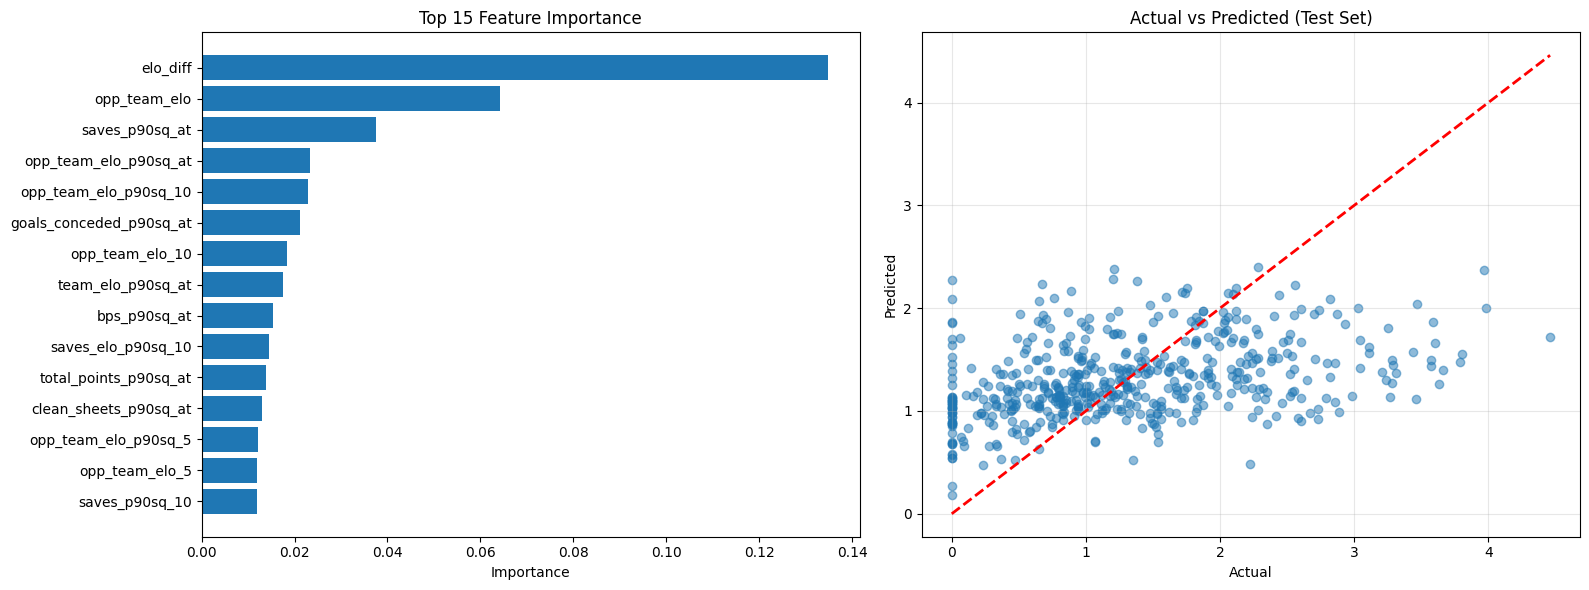

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4156/4647

Training Set Performance:
R² Score: 0.4752
RMSE: 13.3057
MAE: 10.8031

Test Set Performance:
R² Score: 0.0193
RMSE: 18.8200
MAE: 14.6784

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.096290
          opp_team_elo_10    0.026337
             opp_team_elo    0.021510
       opp_team_elo_elo_5    0.017901
  goals_conceded_p90sq_at    0.016895
           opp_team_elo_5    0.015078
      minutes_elo_p90sq_5    0.014340
           opp_team_elo_3    0.014138
           bonus_p90sq_at    0.013051
    opp_team_elo_p90sq_at    0.012223
  clean_sheets_elo_p90_10    0.011199
              bps_p90sq_5    0.011190
    clean_sheets_p90sq_at    0.010899
      clean_sheets_elo_10    0.010645
        minutes_elo_p90_5    0.010518
             bps_p90sq_at    0.010448
total_points_elo_p90sq_10    0.010291
        minutes_elo_p90_3    0.009946
    total_points_p90sq_at    0.009817
     minut

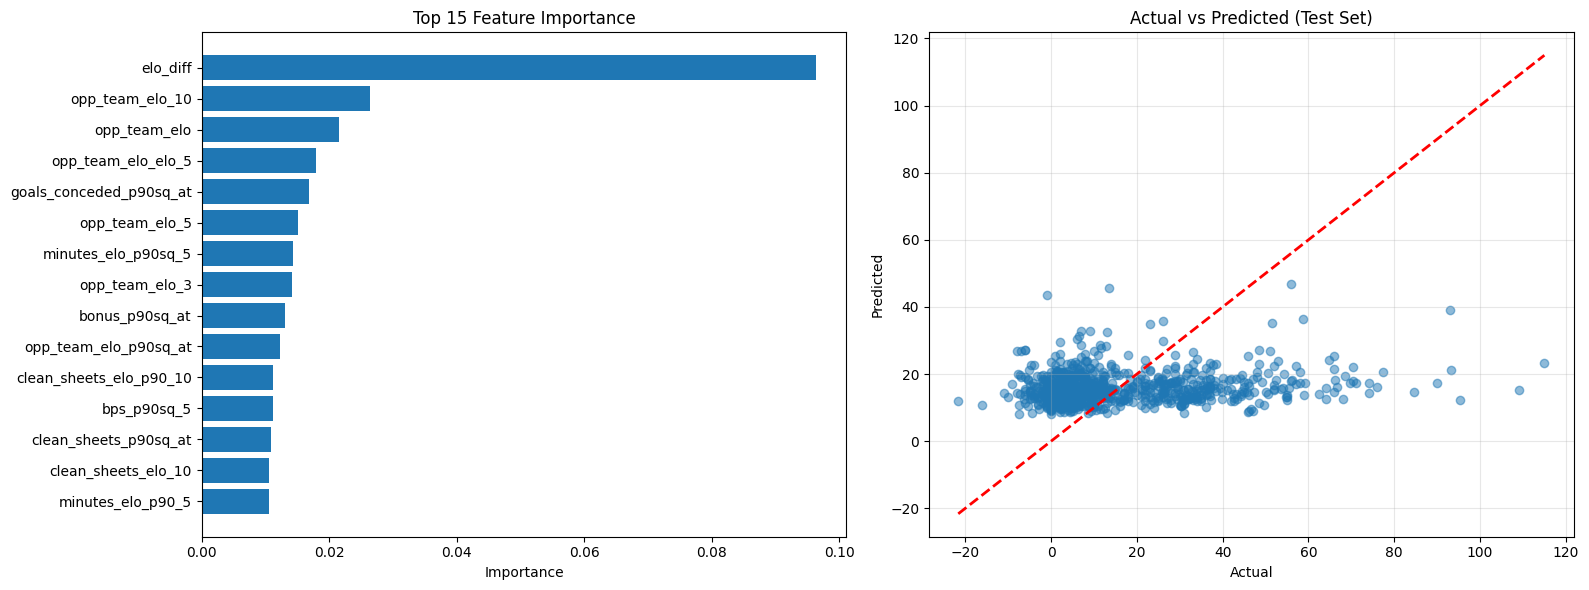

target=bps_per90, MID_bps_predictor
Cleaned df size: 18667/19279

Training Set Performance:
R² Score: 0.3196
RMSE: 9.5126
MAE: 7.2155

Test Set Performance:
R² Score: 0.0406
RMSE: 10.9217
MAE: 8.0226

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.132442
                 bps_10    0.035470
             bps_elo_10    0.031035
         bonus_p90sq_at    0.021275
           opp_team_elo    0.020471
        opp_team_elo_10    0.018958
         opp_team_elo_3    0.013367
           bps_p90sq_at    0.013256
         opp_team_elo_5    0.013037
              bps_elo_5    0.011418
  goals_scored_p90sq_at    0.011268
                  bps_5    0.010751
              bps_p90_3    0.010497
  clean_sheets_p90sq_at    0.010112
      team_elo_p90sq_at    0.009934
    total_points_elo_10    0.009934
    clean_sheets_elo_10    0.009712
         minutes_elo_10    0.009273
goals_conceded_p90sq_at    0.008858
  opp_team_elo_p90sq_10    0.008354


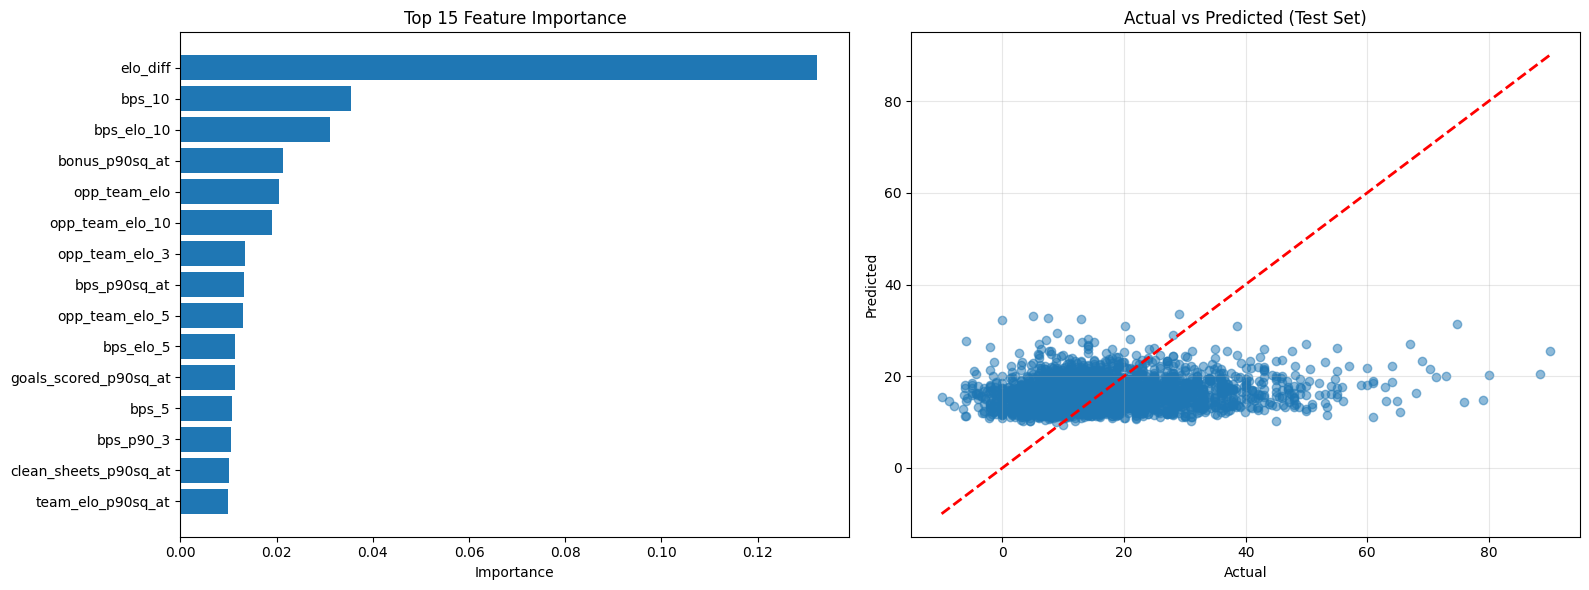

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15999/17005

Training Set Performance:
R² Score: 0.4108
RMSE: 7.6314
MAE: 6.1011

Test Set Performance:
R² Score: 0.1434
RMSE: 9.0163
MAE: 7.0846

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.232131
           opp_team_elo    0.034548
        opp_team_elo_10    0.026593
         opp_team_elo_5    0.022497
         opp_team_elo_3    0.016829
         bonus_p90sq_at    0.014527
            bps_p90sq_5    0.013827
goals_conceded_p90sq_at    0.011973
             bps_p90_10    0.011304
  clean_sheets_p90sq_at    0.011132
            team_elo_10    0.010845
               team_elo    0.010619
             team_elo_5    0.010312
           bps_p90sq_at    0.010084
                 bps_10    0.010004
    minutes_elo_p90sq_3    0.009452
        bps_elo_p90sq_3    0.009409
  opp_team_elo_p90sq_at    0.008953
           bps_p90sq_10    0.008934
             bps_elo_10    0.008772


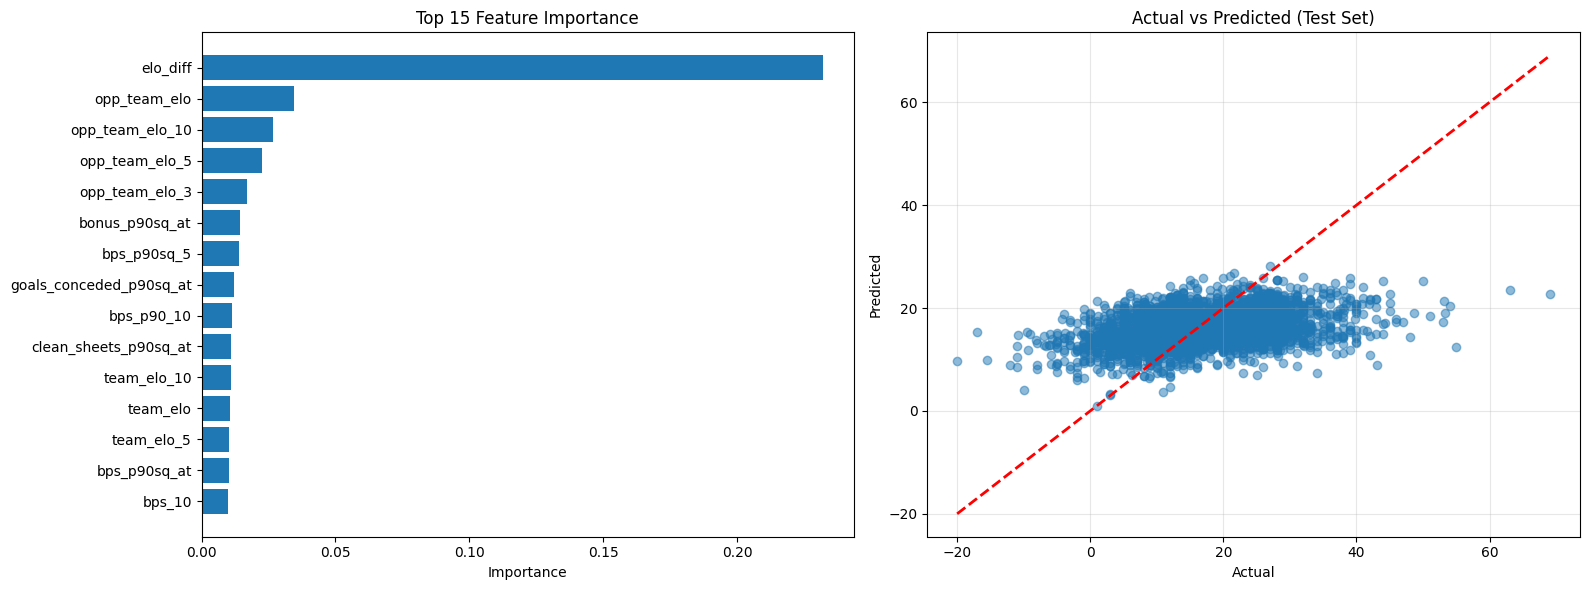

target=bps_per90, GK_bps_predictor
Cleaned df size: 3914/4156

Training Set Performance:
R² Score: 0.5299
RMSE: 6.0886
MAE: 4.9463

Test Set Performance:
R² Score: 0.0564
RMSE: 8.8149
MAE: 7.1290

Top 20 Feature Importances:
                    feature  importance
               opp_team_elo    0.037429
               bps_p90sq_10    0.026591
            opp_team_elo_10    0.024363
      opp_team_elo_p90sq_at    0.023568
               bps_p90sq_at    0.020609
      opp_team_elo_p90sq_10    0.018460
                bps_p90sq_5    0.017402
                   elo_diff    0.017322
                bps_p90sq_3    0.016962
      total_points_p90sq_10    0.016314
             saves_p90sq_at    0.016306
       opp_team_elo_p90sq_3    0.016304
                 bps_p90_10    0.015954
goals_conceded_elo_p90sq_10    0.015884
          saves_elo_p90sq_3    0.015779
             saves_p90sq_10    0.015669
             opp_team_elo_5    0.015443
             opp_team_elo_3    0.015213
             bp

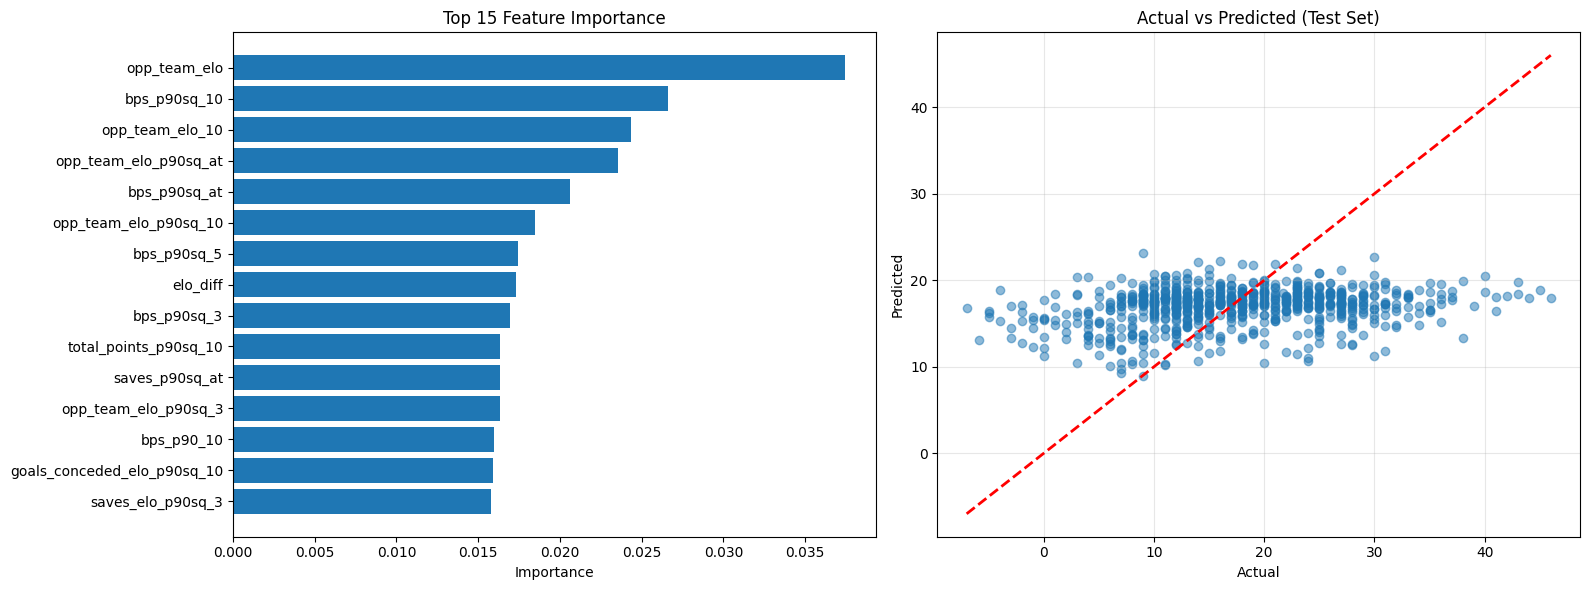

In [ ]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3914/4177

Training Set Performance:
R² Score: 0.5814
RMSE: 1.2747
MAE: 1.0277

Test Set Performance:
R² Score: 0.0565
RMSE: 1.8531
MAE: 1.4837

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.124530
               opp_team_elo    0.023786
             saves_p90sq_at    0.019922
      opp_team_elo_p90sq_at    0.019691
               bps_p90sq_at    0.017511
            opp_team_elo_10    0.017290
             opp_team_elo_5    0.016829
             saves_p90sq_10    0.016155
         saves_elo_p90sq_10    0.014740
             opp_team_elo_3    0.012971
    goals_conceded_p90sq_at    0.012797
   total_points_elo_p90sq_5    0.012784
          team_elo_p90sq_at    0.012441
             bonus_p90sq_at    0.012325
      opp_team_elo_p90sq_10    0.011959
          saves_elo_p90sq_3    0.011427
   total_points_elo_p90sq_3    0.011220
            bps_elo_p90sq_5    0.011142
goals_conce

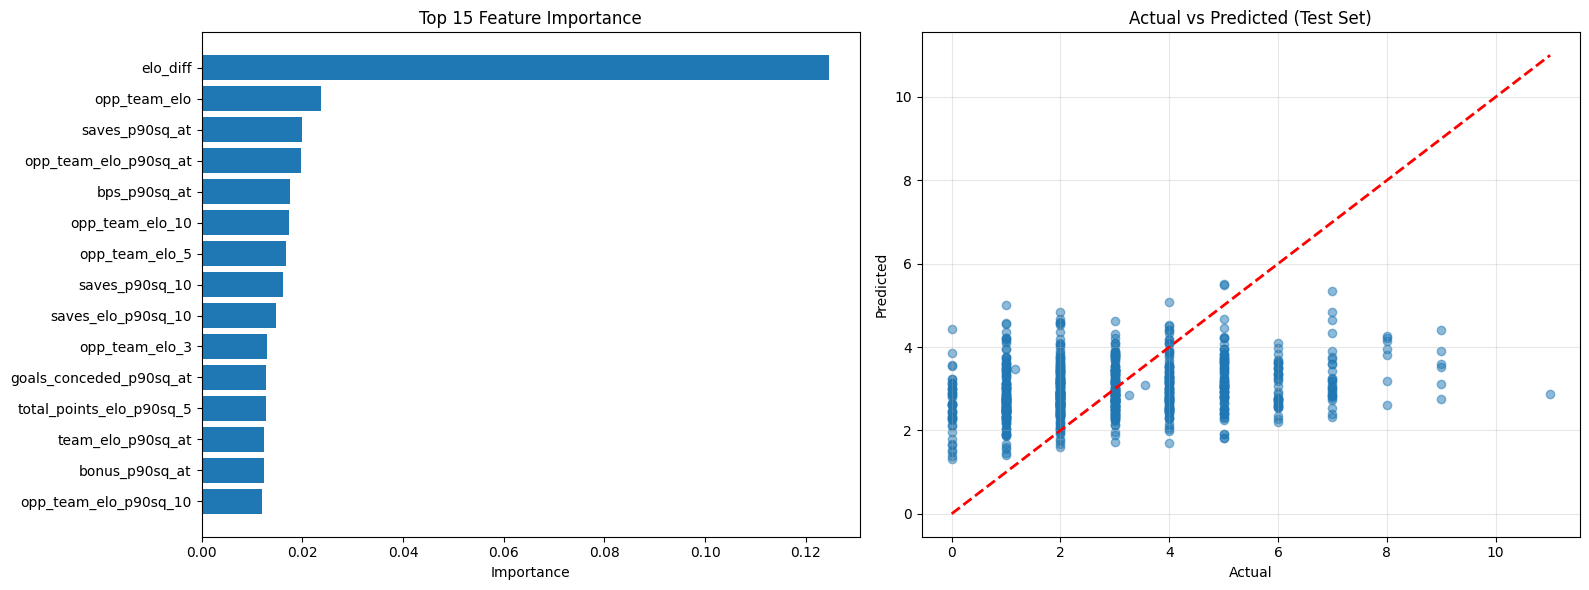

In [ ]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 649/5136

Training Set Performance:
R² Score: 0.8169
RMSE: 1.2153
MAE: 0.9786

Test Set Performance:
R² Score: -0.1132
RMSE: 3.0518
MAE: 2.2658

Top 20 Feature Importances:
                 feature  importance
   clean_sheets_p90sq_at    0.043553
       team_elo_p90sq_10    0.040467
          opp_team_elo_5    0.031409
        team_elo_p90sq_5    0.022489
   goals_scored_p90sq_at    0.019047
          opp_team_elo_3    0.018782
            opp_team_elo    0.017717
   goals_conceded_p90_10    0.016230
         opp_team_elo_10    0.015505
                elo_diff    0.014205
          bonus_p90sq_at    0.013616
      minutes_elo_p90_10    0.013184
         bps_elo_p90sq_5    0.013054
             bps_p90sq_5    0.012980
            bps_p90sq_at    0.012893
       team_elo_p90sq_at    0.012815
         xg_over_g_ratio    0.012806
 goals_conceded_p90sq_at    0.012776
clean_sheets_elo_p90sq_3    0.012754
            

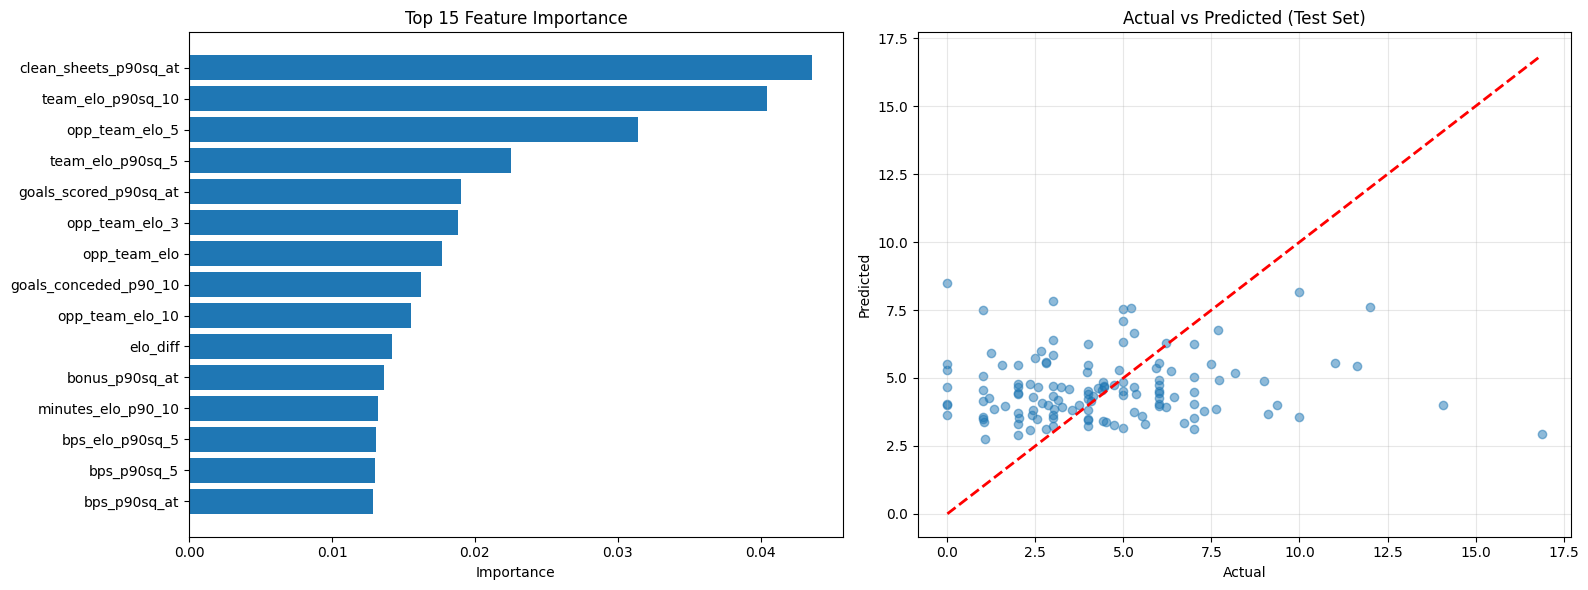

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2942/21204

Training Set Performance:
R² Score: 0.6630
RMSE: 2.4542
MAE: 1.9665

Test Set Performance:
R² Score: 0.1586
RMSE: 3.7881
MAE: 3.0229

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.098829
    goals_conceded_p90sq_at    0.031037
             bonus_p90sq_at    0.029305
      total_points_p90sq_at    0.020252
                   team_elo    0.018344
               bps_p90sq_at    0.017009
                 bps_p90_10    0.013522
               opp_team_elo    0.013479
                      bps_5    0.012460
          team_elo_p90sq_at    0.012250
      opp_team_elo_p90sq_at    0.011901
      goals_conceded_elo_10    0.011219
            opp_team_elo_10    0.011134
                   elo_diff    0.011041
goals_conceded_elo_p90sq_10    0.011001
        team_elo_elo_p90_10    0.010960
             opp_team_elo_5    0.010781
      clean_sheets_p90sq_at    

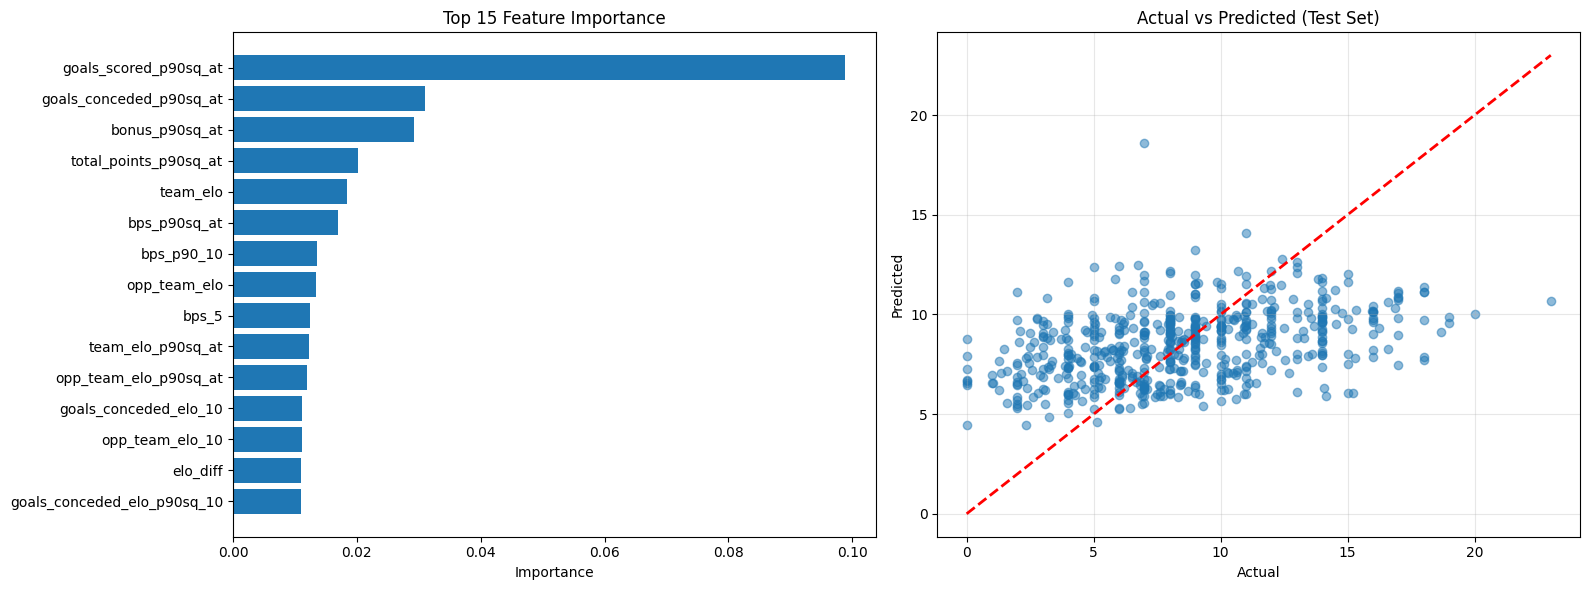

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2461/17971

Training Set Performance:
R² Score: 0.6441
RMSE: 2.3326
MAE: 1.8925

Test Set Performance:
R² Score: 0.0717
RMSE: 3.7043
MAE: 2.8779

Top 20 Feature Importances:
                                   feature  importance
                                cbi_p90_at    0.055130
xgoal_involvements_x_defensive_cont_p90_at    0.027499
                              opp_team_elo    0.020796
                                  elo_diff    0.019875
                       team_elo_elo_p90_10    0.019407
                   goals_conceded_p90sq_at    0.018415
                   opp_team_elo_elo_p90_10    0.018388
                      opp_team_elo_p90sq_5    0.017446
                     opp_team_elo_p90sq_at    0.015555
                            tackles_p90_at    0.015478
                           opp_team_elo_10    0.014359
                     total_points_p90sq_at    0.013968
                            opp_team

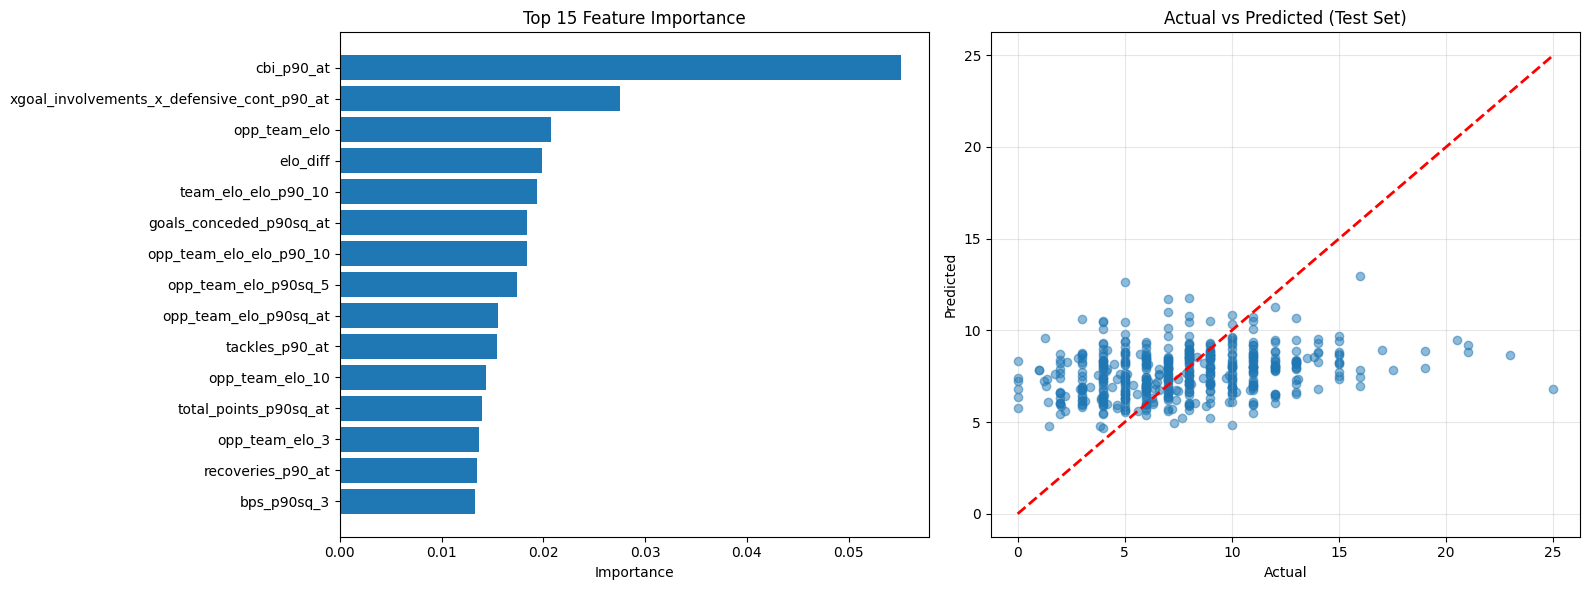

In [ ]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

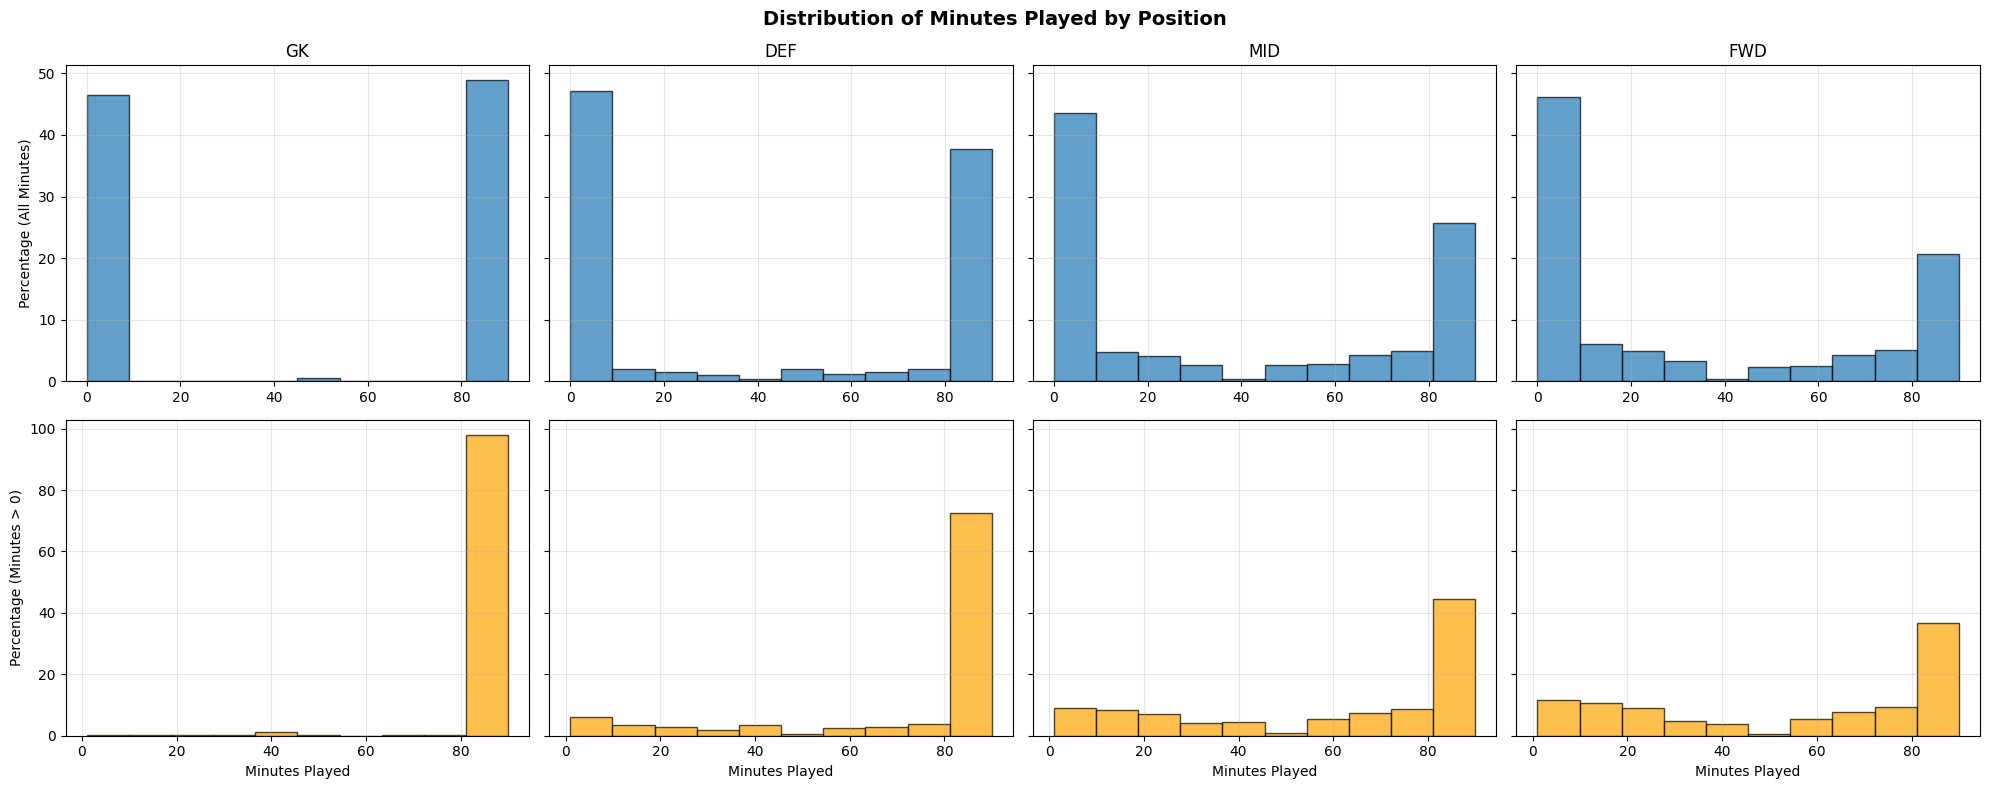

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.357


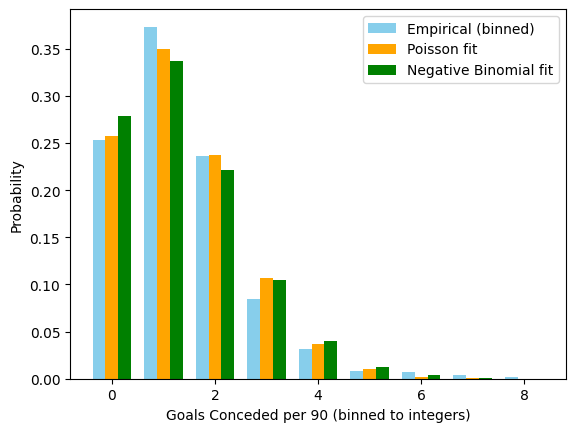

Mean: 1.348, Variance: 1.504
Overdispersion ratio (Var/Mean): 1.116
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.257


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.231


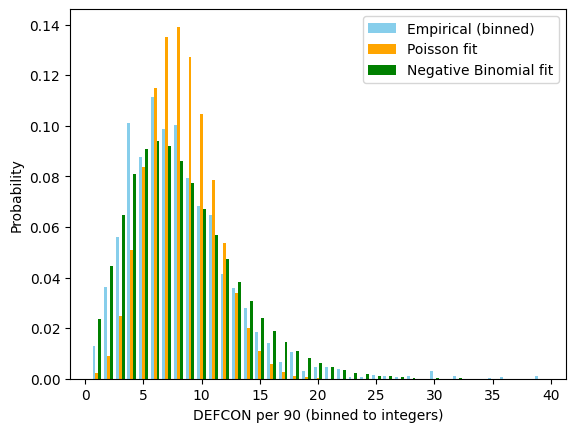

Mean: 8.224, Variance: 21.558
Overdispersion ratio (Var/Mean): 2.621
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [ ]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.199


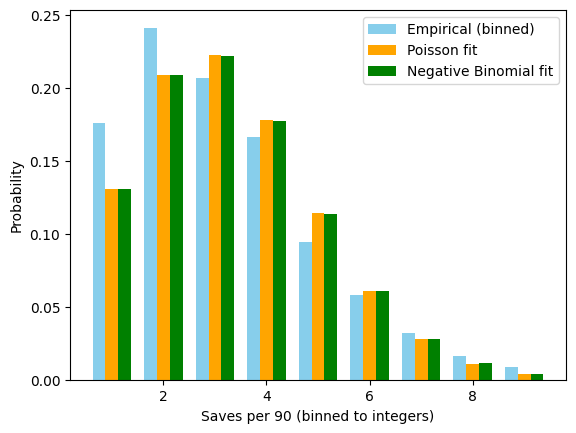

Mean: 3.199, Variance: 3.214
Overdispersion ratio (Var/Mean): 1.005
✅ Poisson assumption looks reasonable.


In [ ]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [ ]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [ ]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [ ]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    4056.000000
mean       60.234218
std        19.939089
min        17.027730
25%        43.077188
50%        60.867832
75%        79.407839
max        89.972308
Name: mins_pred, dtype: float64

In [ ]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    3783.000000
mean        0.165222
std         0.141581
min         0.028165
25%         0.059687
50%         0.127756
75%         0.205220
max         0.777314
Name: xgp90_pred, dtype: float64

In [ ]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    3783.000000
mean        0.106850
std         0.071920
min         0.027566
25%         0.050048
50%         0.080640
75%         0.145923
max         0.355874
Name: xap90_pred, dtype: float64

In [ ]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    4056.000000
mean        1.403938
std         0.305074
min         0.410170
25%         1.189999
50%         1.396965
75%         1.593171
max         2.605552
Name: xgcp90_pred, dtype: float64

In [ ]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    4056.000000
mean       15.838513
std         3.263406
min         5.032090
25%        13.670766
50%        15.361688
75%        17.831377
max        44.620358
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.510e+04
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:42:00   Log-Likelihood:                         -40709.
No. Observations:               43221   AIC:                                  8.142e+04
Df Residuals:                   43220   BIC:                                  8.143e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

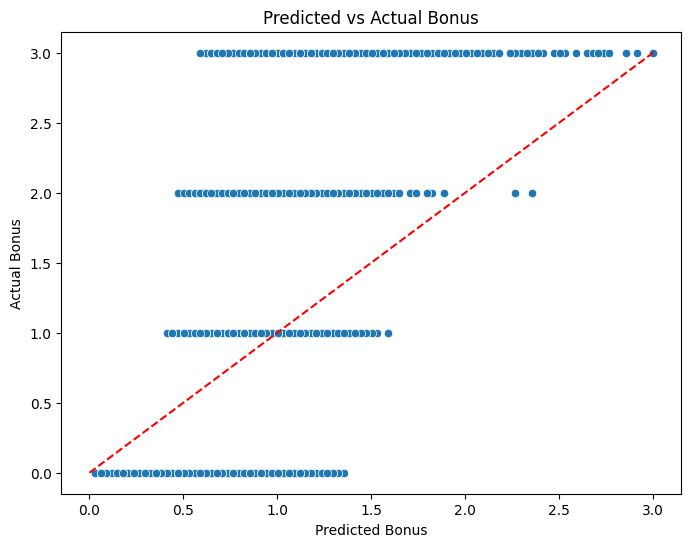

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458819  0.228471  1.105685  1.947012
FWD           0.332191  0.196841  1.046107  1.707198
GK            0.488071  0.244207  1.113851  2.006221
GKP                NaN       NaN       NaN       NaN
MID           0.397325  0.244595  1.047628  1.823045


C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [ ]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [ ]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [ ]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    273.000000
mean       3.148989
std        0.642028
min        1.603282
25%        2.707151
50%        2.961369
75%        3.458820
max        5.205129
Name: xsavesp90_pred, dtype: float64

In [ ]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    3783.000000
mean        7.972125
std         1.842563
min         2.682491
25%         6.717121
50%         8.053484
75%         9.363857
max        15.688597
Name: xdefconp90_pred, dtype: float64

In [ ]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129352,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,31.0,Man Utd,1113.283551,31.585083,0.114990,0.208286,1.769146
129355,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,32.0,Arsenal,1258.933285,32.141506,0.087179,0.198835,1.934892
130033,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1125.802842,33.727434,0.122784,0.071814,1.431185
130035,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,942.107583,34.047245,0.148143,0.111572,1.109327
130043,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1047.736973,33.440347,0.123719,0.080867,1.702919


In [ ]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
138990,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,31.0,Burnley,891.228204,31.135207,0.771916,0.318250,1.974760
141813,Marc Guiu Paz,252.0,41.0,Chelsea,FWD,20252026.0,31.0,Everton,1063.420185,46.908625,0.705441,0.219702,1.480729
130175,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,31.0,Brighton,1080.364275,35.167231,0.697150,0.344325,1.649283
148759,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,31.0,Sunderland,1028.600710,21.221462,0.692897,0.045534,1.759796
132842,Chris Wood,525.0,71.0,Nott'm Forest,FWD,20252026.0,31.0,Spurs,967.256888,37.169525,0.648431,0.306437,1.761080
135380,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,31.0,Leeds,981.708201,34.203339,0.599033,0.303919,1.845686
147270,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,31.0,Liverpool,1163.843221,35.667298,0.592404,0.271620,1.593047
131250,Arnaud Kalimuendo,696.0,60.0,Nott'm Forest,FWD,20252026.0,31.0,Spurs,967.256888,32.387700,0.582826,0.288004,2.012072
145644,Reiss Nelson,27.0,48.0,Brentford,MID,20252026.0,31.0,Leeds,981.708201,36.802294,0.574218,0.280559,1.906602
143975,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1125.802842,37.767228,0.562176,0.267702,2.039945


In [ ]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [ ]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [ ]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_14768\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [ ]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [ ]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4056 entries, 0 to 4055
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          4056 non-null   object 
 1   team_name               4056 non-null   object 
 2   team_elo                4056 non-null   float64
 3   element                 4056 non-null   float64
 4   position                4056 non-null   object 
 5   opp_team_name           4056 non-null   object 
 6   opp_team_elo            4056 non-null   float64
 7   season                  4056 non-null   float64
 8   value                   4056 non-null   float64
 9   event                   4056 non-null   float64
 10  mins_pred               4056 non-null   float64
 11  xgp90_pred              3783 non-null   float64
 12  xap90_pred              3783 non-null   float64
 13  xgcp90_pred             4056 non-null   float64
 14  xpoints_mins            4056 non-null   

In [ ]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [ ]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [ ]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 31 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
148334,Tyrone Mings,40.0,31.0,43.0,Aston Villa,DEF,West Ham,993.767441,75.299155,1.821994,0.253122,0.126083,1.853874,0.0,-0.188209,0.543588,0.576807,4.987259
135192,Ezri Konsa Ngoyo,38.0,31.0,44.0,Aston Villa,DEF,West Ham,993.767441,75.822753,1.829527,0.244835,0.135759,1.818453,0.0,-0.195822,0.543588,0.565077,4.941416
141284,Lucas Digne,37.0,31.0,45.0,Aston Villa,DEF,West Ham,993.767441,72.556477,1.778276,0.220645,0.186800,1.821397,0.0,-0.195181,0.543588,0.566569,4.922095
142797,Matty Cash,36.0,31.0,48.0,Aston Villa,DEF,West Ham,993.767441,75.400249,1.823468,0.216287,0.134409,1.803661,0.0,-0.199069,0.543588,0.552386,4.874730
136501,Harry Wilson,329.0,31.0,60.0,Fulham,MID,Burnley,891.228204,82.127508,1.901389,0.903994,0.525274,0.389670,0.0,0.000000,0.507208,0.644988,4.872523
133054,Cole Palmer,235.0,31.0,106.0,Chelsea,MID,Everton,1063.420185,80.553332,1.886485,1.008842,0.579563,0.234346,0.0,0.000000,0.507208,0.610614,4.827059
130437,Alexis Mac Allister,386.0,31.0,63.0,Liverpool,MID,Brighton,1080.364275,85.074013,1.924659,0.965676,0.541674,0.253179,0.0,0.000000,0.507208,0.633957,4.826354
130269,Alex Iwobi,324.0,31.0,64.0,Fulham,MID,Burnley,891.228204,86.514380,1.934100,0.714405,0.650195,0.373990,0.0,0.000000,0.507208,0.625963,4.805860
140698,Lamare Bogarde,44.0,31.0,40.0,Aston Villa,DEF,West Ham,993.767441,69.861951,1.728336,0.180029,0.127261,1.802393,0.0,-0.199349,0.543588,0.556094,4.738352
131112,Antonee Robinson,316.0,31.0,49.0,Fulham,DEF,Burnley,891.228204,83.046108,1.909258,0.194835,0.133829,1.617713,0.0,-0.243531,0.543588,0.560842,4.716534


In [ ]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW31 - GW35


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,320.124339,7.524489,7.642391,0.700669,5.917341,0.0,-1.179012,2.174351,2.127609,24.907838
15,Alexis Mac Allister,426.695347,9.632355,4.832999,2.740873,1.310991,0.0,0.000000,2.536041,3.162398,24.215657
91,Crysencio Summerville,415.115936,9.545344,4.816346,2.523047,1.407305,0.0,0.000000,2.536041,3.200169,24.028252
86,Cole Palmer,402.705137,9.431806,4.960066,2.657171,1.240477,0.0,0.000000,2.536041,2.915876,23.741438
119,Dominik Szoboszlai,431.352158,9.662908,4.203034,2.871129,1.218210,0.0,0.000000,2.536041,3.007458,23.498781
491,Tyrone Mings,377.120971,9.118934,1.262267,0.628990,8.061742,0.0,-1.258328,2.717939,2.898518,23.430062
144,Ezri Konsa Ngoyo,379.113767,9.147633,1.219284,0.676544,8.070737,0.0,-1.248643,2.717939,2.843163,23.426656
342,Matty Cash,377.143509,9.119406,1.079002,0.603570,8.269107,0.0,-1.186156,2.717939,2.781654,23.384523
64,Bruno Borges Fernandes,394.865508,9.347934,4.324241,2.662137,1.371984,0.0,0.000000,2.536041,3.134154,23.376491
304,Lucas Digne,363.633851,8.905920,1.104507,0.919757,7.998325,0.0,-1.267656,2.717939,2.831969,23.210760


In [ ]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,560.137802,13.167021,13.130772,1.199101,9.961464,0.0,-2.146029,3.805114,3.827384,42.944828
15,Alexis Mac Allister,681.917386,15.406332,7.718881,4.232092,2.039786,0.0,0.000000,4.057666,4.973948,38.428705
91,Crysencio Summerville,663.528722,15.266974,7.636777,3.861807,2.185148,0.0,0.000000,4.057666,5.103497,38.111869
86,Cole Palmer,644.242084,15.090021,8.010428,4.227968,2.064784,0.0,0.000000,4.057666,4.618246,38.069112
64,Bruno Borges Fernandes,631.784813,14.956694,6.969649,4.492743,2.220924,0.0,0.000000,4.057666,5.168803,37.866479
119,Dominik Szoboszlai,690.209545,15.460943,6.702475,4.384528,1.878609,0.0,0.000000,4.057666,4.755622,37.239844
361,Mohamed Salah,562.849761,13.904035,9.518654,3.142574,1.888599,0.0,0.000000,4.057666,4.031593,36.543122
31,Anthony Gordon,660.184816,15.238787,7.905368,2.952500,2.270164,0.0,0.000000,4.057666,3.936370,36.360855
365,Morgan Rogers,671.147328,15.328087,7.140029,3.404954,2.169510,0.0,0.000000,4.057666,4.152390,36.252636
335,Matheus Santos Carneiro da Cunha,679.213911,15.387569,7.240291,2.929718,2.223388,0.0,0.000000,4.057666,4.286384,36.125016


In [ ]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [ ]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [ ]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [ ]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 4056 new predictions to predictions_allgws


In [ ]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points


In [ ]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
183352,Erling Haaland,13.0,20252026.0,2.0,90.0
183353,Erling Haaland,14.0,20252026.0,14.0,90.0
183354,Erling Haaland,15.0,20252026.0,2.0,68.0
183355,Erling Haaland,16.0,20252026.0,13.0,90.0
183356,Erling Haaland,17.0,20252026.0,16.0,90.0
183357,Erling Haaland,18.0,20252026.0,2.0,90.0
183358,Erling Haaland,19.0,20252026.0,2.0,90.0
183359,Erling Haaland,20.0,20252026.0,2.0,90.0
183360,Erling Haaland,21.0,20252026.0,6.0,90.0
183361,Erling Haaland,22.0,20252026.0,2.0,79.0


In [ ]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
65863,Erling Haaland,2026-02-20 10:52:25.776847,38.0,4.434418,NaN
82767,Erling Haaland,2026-02-24 10:14:37.233826,38.0,4.475827,NaN
87905,Erling Haaland,2026-03-09 11:36:31.677192,38.0,4.273248,NaN
92237,Erling Haaland,2026-03-15 09:50:14.619059,38.0,4.089695,NaN


In [ ]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 30.0   3.432445
                                                          31.0   3.432435
                                                          32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
...                                                                   ...
2026-03-16 11:42:07.478367 30                  20252026.0 31.0   3.442896
                                                          32.0   3.462813
                                                          33.0   3.439495
                                                          34.0   3.473355
                                                          35.0   3.462260

[118 rows x 1 columns]

In [ ]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [ ]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [ ]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [ ]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,32.500000
min,2026-01-07 16:29:20.849190,30.000000
25%,2026-01-07 16:29:20.849189888,31.000000
50%,2026-01-08 04:37:05.395073024,32.500000
75%,2026-01-08 16:44:49.940955904,34.000000
max,2026-01-08 16:44:49.940956,35.000000
std,NaN,1.744557


In [ ]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 32.57 minute(s)


In [ ]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)